
# NCA GEDI Algorithm 1 vs Algorithm 5 — Cached Vertical Waveform Diagnostics

This notebook compares GEDI L2A **algorithm setting group 1** and **algorithm setting group 5** for the NCA, while keeping the underlying L1B waveform fixed.

## Primary questions

1. How often do Algorithms 1 and 5 return different numbers of detected modes?
2. When Algorithm 5 detects additional modes, do they correspond to coherent waveform structure or weak/noise-like features?
3. How often does Algorithm 5 shift the lowest-mode elevation relative to Algorithm 1?
4. How sensitive are RH98 and related waveform summaries to algorithm choice?
5. What do those differences look like when the same L1B waveform is displayed physically as:
   - **x-axis:** baseline-corrected receive-waveform DN
   - **y-axis:** height above the algorithm-specific lowest mode
6. Are the differences concentrated in rare failure cases, or do they affect a large fraction of retained shots?

## Important implementation choices

- The quality-filtered science population is held fixed while comparing A1 vs A5.
- Algorithm-specific mode counts use:

\[
K_1 = \texttt{rx\_processing\_a1/rx\_nummodes}
\]

\[
K_5 = \texttt{rx\_processing\_a5/rx\_nummodes}
\]

- `elevs_allmodes_a1/a5` are used for **mode locations**, not for counting modes.
- Root-level `num_detectedmodes` is retained only as an internal check against A1 when `selected_algorithm == 1`.
- Vertical waveform figures use a fixed **−5 to +20 m** display window.
- Extracted shot tables are cached to disk, so the expensive HDF5 traversal does not need to be repeated every notebook run.


In [1]:

# =============================================================================
# 0. IMPORTS, PATHS, AND CACHE CONFIGURATION
# =============================================================================

from pathlib import Path
import re
import json
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm


# -----------------------------------------------------------------------------
# PROJECT PATHS
# -----------------------------------------------------------------------------

ROOT = Path(
    r"A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A"
)

SUBSET_ROOT = (
    ROOT
    / "NCA_spatial_subset_h5"
)

L1B_DIR = (
    SUBSET_ROOT
    / "GEDI01_B"
)

L2A_SUBSET_DIR = (
    SUBSET_ROOT
    / "GEDI02_A"
)


# -----------------------------------------------------------------------------
# OUTPUT / CACHE DIRECTORY
# -----------------------------------------------------------------------------

OUT_DIR = (
    SUBSET_ROOT
    / "algorithm1_vs_algorithm5_vertical_v2"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# -----------------------------------------------------------------------------
# CACHE VERSION
#
# Increment this string if extraction logic changes materially.
# This prevents accidentally loading an older table built under the incorrect
# "count elevs_allmodes entries" mode-count logic.
# -----------------------------------------------------------------------------

CACHE_VERSION = "A1_A5_rx_nummodes_v1"

ALL_SHOTS_PATH = (
    OUT_DIR
    / f"NCA_A1_A5_all_shots_{CACHE_VERSION}.pkl"
)

RETAINED_SHOTS_PATH = (
    OUT_DIR
    / f"NCA_A1_A5_retained_shots_{CACHE_VERSION}.pkl"
)

CACHE_METADATA_PATH = (
    OUT_DIR
    / f"NCA_A1_A5_cache_metadata_{CACHE_VERSION}.json"
)


# -----------------------------------------------------------------------------
# USER CONTROLS
# -----------------------------------------------------------------------------

FORCE_REBUILD_SHOT_TABLE = False

HEIGHT_MIN_M = -5
HEIGHT_MAX_M = 20

RANDOM_SEED = 42


# -----------------------------------------------------------------------------
# SAME PRIMARY SCIENCE FILTER USED IN THE ORIGINAL NCA NOTEBOOK
# -----------------------------------------------------------------------------

ACCEPTED_DEGRADE_FLAGS = {
    0, 3, 10, 13, 20, 23, 30, 33
}

MIN_SENSITIVITY = 0.90

POWER_BEAMS = {
    "BEAM0101",
    "BEAM0110",
    "BEAM1000",
    "BEAM1011",
}


print("L1B directory:")
print(L1B_DIR)

print("\nL2A subset directory:")
print(L2A_SUBSET_DIR)

print("\nOutput directory:")
print(OUT_DIR)

print("\nCache version:")
print(CACHE_VERSION)

print("\nForce rebuild:")
print(FORCE_REBUILD_SHOT_TABLE)


assert L1B_DIR.exists(), L1B_DIR
assert L2A_SUBSET_DIR.exists(), L2A_SUBSET_DIR


L1B directory:
A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA_spatial_subset_h5\GEDI01_B

L2A subset directory:
A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA_spatial_subset_h5\GEDI02_A

Output directory:
A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA_spatial_subset_h5\algorithm1_vs_algorithm5_vertical_v2

Cache version:
A1_A5_rx_nummodes_v1

Force rebuild:
False



## 1. Pair L1B and L2A granules

The spatial L2A subset is used if it contains the algorithm-specific fields. If not, the notebook searches the project root for another copy of the corresponding L2A granules containing A1/A5 outputs.

This keeps the L1B waveform source identical to the original NCA workflow.


In [2]:

# =============================================================================
# 1. FILE DISCOVERY AND GRANULE PAIRING
# =============================================================================

ORBIT_KEY_RE = re.compile(
    r"(O\d{5}_\d{2}_T\d{5}_\d{2})"
)


def orbit_key(path_or_name):
    name = Path(path_or_name).name

    m = ORBIT_KEY_RE.search(name)

    if m is None:
        raise ValueError(
            f"Could not parse GEDI orbit key from {name}"
        )

    return m.group(1)


def list_beams(h5):
    return sorted([
        name
        for name in h5.keys()
        if str(name).startswith("BEAM")
        and isinstance(h5[name], h5py.Group)
    ])


def dataset_exists(group, path):
    try:
        return isinstance(
            group[path],
            h5py.Dataset,
        )
    except Exception:
        return False


def l2a_has_algorithm_fields(path):
    try:
        with h5py.File(path, "r") as h5:

            beams = list_beams(h5)

            if not beams:
                return False

            g = h5[beams[0]]

            candidates = [
                "rx_processing_a1/rx_nummodes",
                "rx_processing_a5/rx_nummodes",
                "geolocation/elev_lowestmode_a1",
                "geolocation/elev_lowestmode_a5",
                "geolocation/elevs_allmodes_a1",
                "geolocation/elevs_allmodes_a5",
                "geolocation/rh_a1",
                "geolocation/rh_a5",
            ]

            return all(
                dataset_exists(g, p)
                for p in candidates
            )

    except Exception:
        return False


l1b_files = sorted(
    L1B_DIR.glob("*.h5")
)

l2a_subset_files = sorted(
    L2A_SUBSET_DIR.glob("*.h5")
)


if not l1b_files:
    raise FileNotFoundError(
        f"No L1B subset files found in {L1B_DIR}"
    )

if not l2a_subset_files:
    raise FileNotFoundError(
        f"No L2A subset files found in {L2A_SUBSET_DIR}"
    )


subset_has_alg_fields = (
    l2a_has_algorithm_fields(
        l2a_subset_files[0]
    )
)


if subset_has_alg_fields:

    l2a_science_files = (
        l2a_subset_files
    )

    print(
        "Using spatial-subset L2A files; "
        "A1/A5 fields are present."
    )

else:

    print(
        "Spatial L2A subset does not expose all required A1/A5 fields."
    )

    print(
        "Searching under ROOT for L2A files containing algorithm-specific products..."
    )

    candidates = [
        p
        for p in ROOT.rglob("*.h5")
        if "GEDI02_A" in p.name
        and p not in l2a_subset_files
    ]

    l2a_science_files = [
        p
        for p in sorted(candidates)
        if l2a_has_algorithm_fields(p)
    ]

    if not l2a_science_files:
        raise FileNotFoundError(
            "No L2A files with the required A1/A5 datasets "
            "were found under ROOT."
        )


l1b_lookup = {
    orbit_key(p): p
    for p in l1b_files
}

l2a_lookup = {
    orbit_key(p): p
    for p in l2a_science_files
}

paired_keys = sorted(
    set(l1b_lookup)
    & set(l2a_lookup)
)


print(
    f"L1B granules:       {len(l1b_lookup):,}"
)

print(
    f"L2A science granules: {len(l2a_lookup):,}"
)

print(
    f"Paired granules:    {len(paired_keys):,}"
)


assert paired_keys, (
    "No L1B/L2A granules paired by orbit key."
)


Using spatial-subset L2A files; A1/A5 fields are present.
L1B granules:       189
L2A science granules: 189
Paired granules:    189



## 2. Inspect the actual A1/A5 datasets

This is intentionally retained as an early diagnostic. It confirms that the local archive really contains the fields used below and displays their shapes.

The key distinction is:

- `rx_processing_a<n>/rx_nummodes` → number of detected modes
- `geolocation/elevs_allmodes_a<n>` → elevations of detected modes


In [3]:

# =============================================================================
# 2. DATASET INVENTORY
# =============================================================================

def inventory_datasets(group):
    rows = []

    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):

            rows.append({
                "path":
                    name,

                "shape":
                    obj.shape,

                "dtype":
                    str(obj.dtype),

                "fill_value":
                    obj.attrs.get(
                        "_FillValue",
                        np.nan,
                    ),
            })

    group.visititems(visitor)

    return pd.DataFrame(rows)


example_key = paired_keys[0]
example_path = l2a_lookup[example_key]


with h5py.File(
    example_path,
    "r",
) as h5:

    example_beam = list_beams(h5)[0]

    inv = inventory_datasets(
        h5[example_beam]
    )


wanted = inv[
    inv["path"].str.contains(
        r"rx_nummodes|rx_modelocs|"
        r"elevs_allmodes_a[15]|"
        r"elev_lowestmode_a[15]|"
        r"elev_lowestreturn_a[15]|"
        r"elev_highestreturn_a[15]|"
        r"rh_a[15]",
        case=False,
        regex=True,
    )
].copy()


print("Example file:")
print(example_path.name)

print("\nExample beam:")
print(example_beam)

display(
    wanted[
        [
            "path",
            "shape",
            "dtype",
            "fill_value",
        ]
    ].reset_index(drop=True)
)


Example file:
GEDI02_A_2019114135421_O02061_02_T00905_02_003_01_V002.h5

Example beam:
BEAM0000


,path,shape,dtype,fill_value
0,geolocation/elev_highestreturn_a1,"(870,)",float32,NaN
1,geolocation/elev_highestreturn_a5,"(870,)",float32,NaN
2,geolocation/elev_lowestmode_a1,"(870,)",float32,NaN
3,geolocation/elev_lowestmode_a5,"(870,)",float32,NaN
4,geolocation/elev_lowestreturn_a1,"(870,)",float32,NaN
5,geolocation/elev_lowestreturn_a5,"(870,)",float32,NaN
6,geolocation/elevs_allmodes_a1,"(870, 20)",float32,NaN
7,geolocation/elevs_allmodes_a5,"(870, 20)",float32,NaN
8,geolocation/rh_a1,"(870, 101)",int16,NaN
9,geolocation/rh_a5,"(870, 101)",int16,NaN



## 3. Extraction helpers

Mode count is read directly from `rx_nummodes`.

Mode elevation arrays are cleaned separately for visualization. Their HDF5 fill value is honored when present. When a waveform's physical vertical extent is available, mode elevations are also restricted to the waveform's plausible elevation support.


In [4]:

# =============================================================================
# 3. GENERIC EXTRACTION HELPERS
# =============================================================================

def get_dataset(
    group,
    candidates,
):

    for path in candidates:

        try:

            obj = group[path]

            if isinstance(
                obj,
                h5py.Dataset,
            ):
                return obj

        except Exception:
            pass

    return None


def read_1d(
    group,
    candidates,
    n=None,
):

    ds = get_dataset(
        group,
        candidates,
    )

    if ds is None:
        return None

    arr = np.asarray(ds)

    if arr.ndim != 1:
        return None

    if (
        n is not None
        and len(arr) != n
    ):
        return None

    return arr


def shot_scalar(
    group,
    candidates,
    i,
):

    ds = get_dataset(
        group,
        candidates,
    )

    if ds is None:
        return np.nan

    try:

        return float(
            np.asarray(ds)[i]
        )

    except Exception:

        return np.nan


def algorithm_nummodes(
    group,
    alg,
    n,
):

    ds = get_dataset(
        group,
        [
            f"rx_processing_a{alg}/rx_nummodes",
        ],
    )

    if ds is None:
        return np.full(
            n,
            np.nan,
        )

    arr = np.asarray(ds)

    if (
        arr.ndim == 1
        and len(arr) == n
    ):

        return arr.astype(float)

    return np.full(
        n,
        np.nan,
    )


def valid_mode_elevations(
    group,
    alg,
    shot_index,
    waveform_z_min=None,
    waveform_z_max=None,
):

    ds = get_dataset(
        group,
        [
            f"geolocation/elevs_allmodes_a{alg}",
            f"elevs_allmodes_a{alg}",
        ],
    )

    if ds is None:

        return np.array(
            [],
            dtype=float,
        )

    vals = np.asarray(
        ds[shot_index],
        dtype=float,
    ).ravel()

    valid = np.isfinite(vals)


    # -------------------------------------------------------------------------
    # Respect HDF5 fill metadata if present.
    # -------------------------------------------------------------------------

    fill = ds.attrs.get(
        "_FillValue",
        None,
    )

    if fill is not None:

        fill_vals = np.asarray(
            fill
        ).ravel()

        if len(fill_vals):

            fv = float(
                fill_vals[0]
            )

            valid &= ~np.isclose(
                vals,
                fv,
                rtol=0,
                atol=1e-8,
            )


    vals = vals[
        valid
    ]


    # -------------------------------------------------------------------------
    # Restrict to plausible L1B waveform support if available.
    # -------------------------------------------------------------------------

    if (
        waveform_z_min is not None
        and waveform_z_max is not None
        and np.isfinite(
            waveform_z_min
        )
        and np.isfinite(
            waveform_z_max
        )
    ):

        lo = (
            min(
                waveform_z_min,
                waveform_z_max,
            )
            - 5.0
        )

        hi = (
            max(
                waveform_z_min,
                waveform_z_max,
            )
            + 5.0
        )

        vals = vals[
            (vals >= lo)
            & (vals <= hi)
        ]


    return np.sort(
        np.unique(vals)
    )


def rh98_for_algorithm(
    group,
    alg,
    shot_index,
):

    ds = get_dataset(
        group,
        [
            f"geolocation/rh_a{alg}",
            f"rh_a{alg}",
        ],
    )

    if ds is None:
        return np.nan

    arr = np.asarray(
        ds[shot_index],
        dtype=float,
    ).ravel()

    if len(arr) <= 98:
        return np.nan

    value = float(
        arr[98]
    )

    # Algorithm-specific RH arrays are commonly stored in cm.
    # Convert when magnitude clearly indicates that representation.
    if (
        np.isfinite(value)
        and abs(value) > 50
    ):

        value /= 100.0

    return value



## 4. Build or load cached shot tables

Two tables are written:

- **all shots**: every extracted shot from the paired L2A granules
- **retained shots**: the same primary quality-filtered NCA science population used previously

If a valid cache already exists, this section loads it and skips HDF5 traversal.


In [5]:

# =============================================================================
# 4. SHOT-TABLE EXTRACTION
# =============================================================================

def extract_l2a_algorithm_table(
    path,
    granule_key,
):

    parts = []


    with h5py.File(
        path,
        "r",
    ) as h5:


        for beam in list_beams(h5):

            g = h5[beam]


            shot_ds = get_dataset(
                g,
                [
                    "shot_number",
                    "geolocation/shot_number",
                ],
            )


            if shot_ds is None:
                continue


            shots = np.asarray(
                shot_ds
            ).astype(
                np.uint64
            )

            n = len(
                shots
            )


            q = read_1d(
                g,
                ["quality_flag"],
                n=n,
            )

            deg = read_1d(
                g,
                [
                    "degrade_flag",
                    "geolocation/degrade_flag",
                ],
                n=n,
            )

            sens = read_1d(
                g,
                ["sensitivity"],
                n=n,
            )

            selected_algorithm = read_1d(
                g,
                ["selected_algorithm"],
                n=n,
            )

            root_k = read_1d(
                g,
                ["num_detectedmodes"],
                n=n,
            )


            # -------------------------------------------------------------
            # Algorithm-specific mode count arrays — read directly.
            # -------------------------------------------------------------

            k_a1 = algorithm_nummodes(
                g,
                alg=1,
                n=n,
            )

            k_a5 = algorithm_nummodes(
                g,
                alg=5,
                n=n,
            )


            rows = []


            for i, shot in enumerate(
                shots
            ):


                rows.append({

                    "granule_key":
                        granule_key,

                    "beam":
                        beam,

                    "shot_number":
                        shot,

                    "quality_flag":
                        (
                            q[i]
                            if q is not None
                            else np.nan
                        ),

                    "degrade_flag":
                        (
                            deg[i]
                            if deg is not None
                            else np.nan
                        ),

                    "sensitivity":
                        (
                            sens[i]
                            if sens is not None
                            else np.nan
                        ),

                    "selected_algorithm":
                        (
                            selected_algorithm[i]
                            if selected_algorithm is not None
                            else np.nan
                        ),

                    "num_detectedmodes_root":
                        (
                            root_k[i]
                            if root_k is not None
                            else np.nan
                        ),

                    "K_a1":
                        k_a1[i],

                    "K_a5":
                        k_a5[i],


                    "elev_lowestmode_a1":
                        shot_scalar(
                            g,
                            [
                                "geolocation/elev_lowestmode_a1",
                                "elev_lowestmode_a1",
                            ],
                            i,
                        ),

                    "elev_lowestmode_a5":
                        shot_scalar(
                            g,
                            [
                                "geolocation/elev_lowestmode_a5",
                                "elev_lowestmode_a5",
                            ],
                            i,
                        ),


                    "elev_lowestreturn_a1":
                        shot_scalar(
                            g,
                            [
                                "geolocation/elev_lowestreturn_a1",
                                "elev_lowestreturn_a1",
                            ],
                            i,
                        ),

                    "elev_lowestreturn_a5":
                        shot_scalar(
                            g,
                            [
                                "geolocation/elev_lowestreturn_a5",
                                "elev_lowestreturn_a5",
                            ],
                            i,
                        ),


                    "elev_highestreturn_a1":
                        shot_scalar(
                            g,
                            [
                                "geolocation/elev_highestreturn_a1",
                                "elev_highestreturn_a1",
                            ],
                            i,
                        ),

                    "elev_highestreturn_a5":
                        shot_scalar(
                            g,
                            [
                                "geolocation/elev_highestreturn_a5",
                                "elev_highestreturn_a5",
                            ],
                            i,
                        ),


                    "rh98_a1":
                        rh98_for_algorithm(
                            g,
                            alg=1,
                            shot_index=i,
                        ),

                    "rh98_a5":
                        rh98_for_algorithm(
                            g,
                            alg=5,
                            shot_index=i,
                        ),
                })


            parts.append(
                pd.DataFrame(
                    rows
                )
            )


    if not parts:

        return pd.DataFrame()


    return pd.concat(
        parts,
        ignore_index=True,
    )


In [6]:

# =============================================================================
# 5. LOAD CACHE OR BUILD TABLES
# =============================================================================

cache_available = (
    ALL_SHOTS_PATH.exists()
    and RETAINED_SHOTS_PATH.exists()
    and CACHE_METADATA_PATH.exists()
)

cache_valid = False


if cache_available:

    try:

        with open(
            CACHE_METADATA_PATH,
            "r",
            encoding="utf-8",
        ) as f:

            cache_meta = json.load(
                f
            )

        cache_valid = (
            cache_meta.get(
                "cache_version"
            )
            == CACHE_VERSION
        )

    except Exception as exc:

        print(
            "Could not read cache metadata:"
        )

        print(
            repr(exc)
        )

        cache_valid = False


if (
    cache_available
    and cache_valid
    and not FORCE_REBUILD_SHOT_TABLE
):

    print(
        "Loading existing A1/A5 shot-table cache..."
    )

    shots = pd.read_pickle(
        ALL_SHOTS_PATH
    )

    gedi_keep = pd.read_pickle(
        RETAINED_SHOTS_PATH
    )


else:

    if FORCE_REBUILD_SHOT_TABLE:

        print(
            "FORCE_REBUILD_SHOT_TABLE=True"
        )

    elif not cache_available:

        print(
            "Complete cache not found."
        )

    elif not cache_valid:

        print(
            "Cache version mismatch."
        )


    print(
        "\nBuilding A1/A5 shot table from HDF5..."
    )


    parts = []


    for key in tqdm(
        paired_keys,
        desc="Extracting A1/A5 L2A products",
    ):

        df = extract_l2a_algorithm_table(
            l2a_lookup[key],
            key,
        )

        if not df.empty:

            parts.append(
                df
            )


    if not parts:

        raise RuntimeError(
            "No A1/A5 shot records were extracted."
        )


    shots = pd.concat(
        parts,
        ignore_index=True,
    )


    # =========================================================================
    # PRIMARY SCIENCE FILTER
    # =========================================================================

    sens = pd.to_numeric(
        shots["sensitivity"],
        errors="coerce",
    )

    q = pd.to_numeric(
        shots["quality_flag"],
        errors="coerce",
    )

    deg = pd.to_numeric(
        shots["degrade_flag"],
        errors="coerce",
    )


    keep_mask = (
        q.eq(1)
        & deg.isin(
            ACCEPTED_DEGRADE_FLAGS
        )
        & sens.between(
            0,
            1,
            inclusive="both",
        )
        & sens.ge(
            MIN_SENSITIVITY
        )
    )


    gedi_keep = (
        shots.loc[
            keep_mask
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )


    # =========================================================================
    # DERIVED A1/A5 COMPARISON FIELDS
    # =========================================================================

    gedi_keep[
        "delta_K_a5_minus_a1"
    ] = (
        gedi_keep[
            "K_a5"
        ]
        - gedi_keep[
            "K_a1"
        ]
    )

    gedi_keep[
        "delta_ground_a5_minus_a1_m"
    ] = (
        gedi_keep[
            "elev_lowestmode_a5"
        ]
        - gedi_keep[
            "elev_lowestmode_a1"
        ]
    )

    gedi_keep[
        "delta_rh98_a5_minus_a1_m"
    ] = (
        gedi_keep[
            "rh98_a5"
        ]
        - gedi_keep[
            "rh98_a1"
        ]
    )


    # =========================================================================
    # WRITE CACHE
    # =========================================================================

    shots.to_pickle(
        ALL_SHOTS_PATH
    )

    gedi_keep.to_pickle(
        RETAINED_SHOTS_PATH
    )


    cache_meta = {

        "cache_version":
            CACHE_VERSION,

        "n_all_shots":
            int(
                len(shots)
            ),

        "n_retained_shots":
            int(
                len(gedi_keep)
            ),

        "quality_filter": {

            "quality_flag":
                1,

            "accepted_degrade_flags":
                sorted(
                    ACCEPTED_DEGRADE_FLAGS
                ),

            "minimum_sensitivity":
                MIN_SENSITIVITY,
        },

        "mode_count_source": {

            "algorithm_1":
                "rx_processing_a1/rx_nummodes",

            "algorithm_5":
                "rx_processing_a5/rx_nummodes",
        },

        "mode_location_source": {

            "algorithm_1":
                "geolocation/elevs_allmodes_a1",

            "algorithm_5":
                "geolocation/elevs_allmodes_a5",
        },
    }


    with open(
        CACHE_METADATA_PATH,
        "w",
        encoding="utf-8",
    ) as f:

        json.dump(
            cache_meta,
            f,
            indent=2,
        )


    print(
        "\nCache written."
    )


print()
print(
    f"All shots:      {len(shots):,}"
)

print(
    f"Retained shots: {len(gedi_keep):,}"
)

print(
    f"Retention:      "
    f"{100 * len(gedi_keep) / len(shots):.2f}%"
)

display(
    gedi_keep.head()
)


Complete cache not found.

Building A1/A5 shot table from HDF5...


Extracting A1/A5 L2A products:   0%|          | 0/189 [00:00<?, ?it/s]


Cache written.

All shots:      1,319,778
Retained shots: 477,023
Retention:      36.14%


,granule_key,beam,shot_number,quality_flag,degrade_flag,sensitivity,selected_algorithm,num_detectedmodes_root,K_a1,K_a5,...,elev_lowestmode_a5,elev_lowestreturn_a1,elev_lowestreturn_a5,elev_highestreturn_a1,elev_highestreturn_a5,rh98_a1,rh98_a5,delta_K_a5_minus_a1,delta_ground_a5_minus_a1_m,delta_rh98_a5_minus_a1_m
0,O02061_02_T00905_02,BEAM0000,20610000200092327,1,0,0.902113,1,1,1.0,1.0,...,768.291443,765.107544,763.946350,771.775085,771.775085,2.69,2.47,0.0,0.000000,-0.22
1,O02061_02_T00905_02,BEAM0000,20610000200092328,1,0,0.923635,1,1,1.0,1.0,...,768.783447,765.075073,762.865051,771.929932,771.929932,2.43,2.02,0.0,0.037476,-0.41
2,O02061_02_T00905_02,BEAM0000,20610000200092329,1,0,0.930495,1,1,1.0,1.0,...,768.713074,764.892334,763.319092,772.121765,772.121765,2.62,2.21,0.0,0.074890,-0.41
3,O02061_02_T00905_02,BEAM0000,20610000200092330,1,0,0.937379,1,1,1.0,1.0,...,769.012390,765.079285,763.393677,772.308716,772.308716,2.50,2.06,0.0,0.074951,-0.44
4,O02061_02_T00905_02,BEAM0000,20610000200092331,1,0,0.941500,1,1,1.0,1.0,...,769.372620,765.177368,763.791382,772.818787,772.818787,2.54,2.21,0.0,0.000000,-0.33



## 5. Internal validation: does A1 reproduce the root selected mode count?

For shots where `selected_algorithm == 1`, `K_a1` should agree with root-level `num_detectedmodes`.

This is the first check that the A1/A5 extraction is wired correctly.


In [7]:

# =============================================================================
# 6. INTERNAL A1 VALIDATION
# =============================================================================

check = gedi_keep[
    pd.to_numeric(
        gedi_keep[
            "selected_algorithm"
        ],
        errors="coerce",
    )
    == 1
].copy()


comparison = (
    check[
        [
            "num_detectedmodes_root",
            "K_a1",
        ]
    ]
    .dropna()
)


print(
    "Root selected mode count × Algorithm-1 rx_nummodes"
)

display(
    pd.crosstab(
        comparison[
            "num_detectedmodes_root"
        ].astype(int),

        comparison[
            "K_a1"
        ].astype(int),

        margins=True,
    )
)


match_rate = np.mean(
    comparison[
        "num_detectedmodes_root"
    ].astype(int)
    ==
    comparison[
        "K_a1"
    ].astype(int)
)


print(
    f"\nExact agreement: "
    f"{100 * match_rate:.5f}%"
)


Root selected mode count × Algorithm-1 rx_nummodes


K_a1,1,2,3,4,5,6,All
num_detectedmodes_root,,,,,,,
1,472352,0,0,0,0,0,472352
2,0,3857,0,0,0,0,3857
3,0,0,676,0,0,0,676
4,0,0,0,116,0,0,116
5,0,0,0,0,18,0,18
6,0,0,0,0,0,4,4
All,472352,3857,676,116,18,4,477023



Exact agreement: 100.00000%



## 6. Population-level A1 vs A5 sensitivity

These summaries answer how much the processing choice changes the interpretation before we inspect individual waveforms.


In [8]:

# =============================================================================
# 7. MODE DISTRIBUTIONS AND A1 × A5 CROSS-TAB
# =============================================================================

def mode_summary(
    df,
    col,
):

    out = (
        pd.to_numeric(
            df[col],
            errors="coerce",
        )
        .dropna()
        .astype(int)
        .value_counts()
        .sort_index()
        .rename("n")
        .to_frame()
    )

    out[
        "percent"
    ] = (
        100
        * out["n"]
        / out["n"].sum()
    )

    return out


print(
    "Algorithm 1 mode count"
)

display(
    mode_summary(
        gedi_keep,
        "K_a1",
    )
)


print(
    "Algorithm 5 mode count"
)

display(
    mode_summary(
        gedi_keep,
        "K_a5",
    )
)


print(
    "Algorithm 1 × Algorithm 5"
)

display(
    pd.crosstab(
        pd.to_numeric(
            gedi_keep[
                "K_a1"
            ],
            errors="coerce",
        ),

        pd.to_numeric(
            gedi_keep[
                "K_a5"
            ],
            errors="coerce",
        ),

        margins=True,
    )
)


Algorithm 1 mode count


,n,percent
K_a1,,
1,472352,99.020802
2,3857,0.808556
3,676,0.141712
4,116,0.024317
5,18,0.003773
6,4,0.000839


Algorithm 5 mode count


,n,percent
K_a5,,
1,408057,85.542416
2,53699,11.257109
3,8637,1.810605
4,2527,0.529744
5,1161,0.243384
6,632,0.132488
7,384,0.080499
8,238,0.049893
9,141,0.029558


Algorithm 1 × Algorithm 5


K_a5,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,...,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,All
K_a1,,,,,,,,,,,,,,,,,,,,,
1.0,408057,52406,7723,1757,647,268,156,108,60,101,...,109,90,109,103,87,92,72,70,266,472352
2.0,0,1293,839,647,385,234,137,62,36,17,...,6,6,12,11,13,12,13,15,108,3857
3.0,0,0,75,119,114,111,68,49,30,13,...,2,1,2,6,5,6,8,4,57,676
4.0,0,0,0,4,14,18,21,18,10,3,...,2,1,0,1,0,2,2,2,12,116
5.0,0,0,0,0,1,1,2,0,4,2,...,1,1,0,0,0,0,0,1,4,18
6.0,0,0,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,1,1,4
All,408057,53699,8637,2527,1161,632,384,238,141,136,...,120,99,123,121,105,112,95,93,448,477023


In [9]:

# =============================================================================
# 8. A1/A5 DIFFERENCE DISTRIBUTIONS
# =============================================================================

display(
    gedi_keep[
        [
            "delta_K_a5_minus_a1",
            "delta_ground_a5_minus_a1_m",
            "delta_rh98_a5_minus_a1_m",
        ]
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
    .T
)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
delta_K_a5_minus_a1,477023.0,0.228396,1.000790,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,1.000000,3.000000,19.000000
delta_ground_a5_minus_a1_m,477023.0,-0.929116,3.290919,-144.010254,-11.349468,-7.566284,0.00,0.074585,0.074951,0.149719,0.223572,43.890381
delta_rh98_a5_minus_a1_m,477023.0,0.602001,3.301388,-44.040000,-0.600000,-0.560000,-0.49,-0.410000,-0.260000,7.260000,11.100000,143.670000


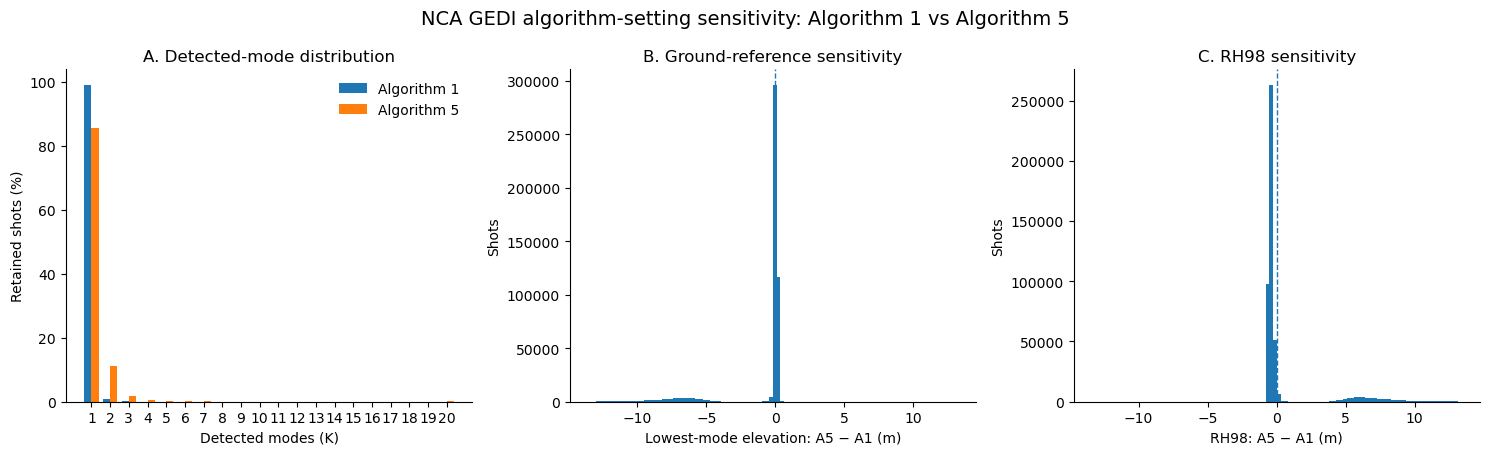

In [10]:

# =============================================================================
# 9. CLEAN POPULATION COMPARISON FIGURE
# =============================================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(
        15,
        4.6,
    ),
)


# -----------------------------------------------------------------------------
# A. MODE DISTRIBUTIONS
# -----------------------------------------------------------------------------

d1 = mode_summary(
    gedi_keep,
    "K_a1",
)

d5 = mode_summary(
    gedi_keep,
    "K_a5",
)


ks = sorted(
    set(d1.index)
    | set(d5.index)
)

xx = np.arange(
    len(ks)
)

width = 0.38


p1 = [
    (
        d1.loc[
            k,
            "percent",
        ]
        if k in d1.index
        else 0
    )
    for k in ks
]

p5 = [
    (
        d5.loc[
            k,
            "percent",
        ]
        if k in d5.index
        else 0
    )
    for k in ks
]


axes[0].bar(
    xx - width / 2,
    p1,
    width=width,
    label="Algorithm 1",
)

axes[0].bar(
    xx + width / 2,
    p5,
    width=width,
    label="Algorithm 5",
)

axes[0].set_xticks(
    xx,
    [
        str(k)
        for k in ks
    ],
)

axes[0].set_xlabel(
    "Detected modes (K)"
)

axes[0].set_ylabel(
    "Retained shots (%)"
)

axes[0].set_title(
    "A. Detected-mode distribution"
)

axes[0].legend(
    frameon=False
)


# -----------------------------------------------------------------------------
# B. GROUND REFERENCE SHIFT
# -----------------------------------------------------------------------------

x = (
    gedi_keep[
        "delta_ground_a5_minus_a1_m"
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .dropna()
)


if len(x):

    lim = max(
        0.5,
        float(
            np.quantile(
                np.abs(x),
                0.995,
            )
        ),
    )

    axes[1].hist(
        x[
            np.abs(x)
            <= lim
        ],
        bins=100,
    )

    axes[1].axvline(
        0,
        linestyle="--",
        linewidth=1,
    )


axes[1].set_xlabel(
    "Lowest-mode elevation: A5 − A1 (m)"
)

axes[1].set_ylabel(
    "Shots"
)

axes[1].set_title(
    "B. Ground-reference sensitivity"
)


# -----------------------------------------------------------------------------
# C. RH98 SHIFT
# -----------------------------------------------------------------------------

x = (
    gedi_keep[
        "delta_rh98_a5_minus_a1_m"
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .dropna()
)


if len(x):

    lim = max(
        1.0,
        float(
            np.quantile(
                np.abs(x),
                0.995,
            )
        ),
    )

    axes[2].hist(
        x[
            np.abs(x)
            <= lim
        ],
        bins=100,
    )

    axes[2].axvline(
        0,
        linestyle="--",
        linewidth=1,
    )


axes[2].set_xlabel(
    "RH98: A5 − A1 (m)"
)

axes[2].set_ylabel(
    "Shots"
)

axes[2].set_title(
    "C. RH98 sensitivity"
)


for ax in axes:

    ax.spines[
        "top"
    ].set_visible(
        False
    )

    ax.spines[
        "right"
    ].set_visible(
        False
    )


fig.suptitle(
    "NCA GEDI algorithm-setting sensitivity: Algorithm 1 vs Algorithm 5",
    fontsize=14,
)

fig.tight_layout()

plt.show()



## 7. Cached A1/A5 Gaussian decomposition

This section adds the expensive Gaussian decomposition to the A1-vs-A5 workflow.

- Algorithm 1 uses `K_a1 = rx_processing_a1/rx_nummodes`.
- Algorithm 5 uses `K_a5 = rx_processing_a5/rx_nummodes`.
- The same L1B fitting engine is used for both.
- Final outputs, checkpoints, and metadata are written separately for A1 and A5.
- Completed outputs are loaded by default instead of recomputed.
- The already-completed original NCA GEDI-K run can be imported as the A1 cache.
- The FINESST maximum of seven Gaussian components is respected: shots with algorithm-specific `K > 7` are flagged and skipped rather than silently capped.


In [11]:

# =============================================================================
# 15. GAUSSIAN CACHE / FIT CONFIGURATION
# =============================================================================

from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks, peak_widths
from scipy.optimize import least_squares

RUN_GAUSSIAN_A1 = True
RUN_GAUSSIAN_A5 = True

FORCE_REBUILD_GAUSSIAN_A1 = False
FORCE_REBUILD_GAUSSIAN_A5 = False

# Reuse the completed original NCA Gaussian run for A1 if available.
IMPORT_LEGACY_A1_CACHE = True

GAUSSIAN_FIT_VERSION = "fixedK_peakinit_v1"

MAX_GAUSSIAN_COMPONENTS = 7

BASELINE_EDGE_FRACTION = 0.15
INITIALIZATION_SMOOTH_SIGMA = 1.5
MIN_INITIAL_PEAK_DISTANCE = 3

MIN_SIGMA_SAMPLES = 0.75
MAX_SIGMA_SAMPLES = 100.0

GAUSSIAN_ROOT = (
    OUT_DIR
    / "gaussian_decomposition"
    / GAUSSIAN_FIT_VERSION
)

GAUSSIAN_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

# Original completed NCA run from the waveform-quality notebook.
LEGACY_A1_DIR = (
    SUBSET_ROOT
    / "derived_waveform_fits"
    / "GEDI_mode_constrained"
)

LEGACY_A1_FITS = (
    LEGACY_A1_DIR
    / "NCA_waveform_fits_GEDI_K.pkl"
)

LEGACY_A1_COMPONENTS = (
    LEGACY_A1_DIR
    / "NCA_gaussian_components_GEDI_K.pkl"
)

print("Gaussian fit version:", GAUSSIAN_FIT_VERSION)
print("Gaussian root:", GAUSSIAN_ROOT)
print("Legacy A1 fits found:", LEGACY_A1_FITS.exists())
print("Legacy A1 components found:", LEGACY_A1_COMPONENTS.exists())


Gaussian fit version: fixedK_peakinit_v1
Gaussian root: A:\NCA_DATA\GEDI\NCA_template_bbox_L1B_L2A\NCA_spatial_subset_h5\algorithm1_vs_algorithm5_vertical_v2\gaussian_decomposition\fixedK_peakinit_v1
Legacy A1 fits found: True
Legacy A1 components found: True


In [12]:

# =============================================================================
# 16. GAUSSIAN MODEL / FITTING HELPERS
# =============================================================================

def gaussian_sum(x, params):
    y = np.zeros_like(x, dtype=float)
    K = len(params) // 3

    for k in range(K):
        A = params[3*k]
        mu = params[3*k + 1]
        sigma = params[3*k + 2]

        y += (
            A
            * np.exp(
                -0.5
                * ((x - mu) / sigma) ** 2
            )
        )

    return y


def prepare_waveform_fixedK(rx):
    rx = np.asarray(rx, dtype=float)

    if len(rx) < 20 or not np.isfinite(rx).all():
        return None

    n_edge = max(
        5,
        int(len(rx) * BASELINE_EDGE_FRACTION),
    )

    background = np.concatenate([
        rx[:n_edge],
        rx[-n_edge:],
    ])

    baseline = np.nanmedian(background)
    corrected = rx - baseline

    mad = np.nanmedian(
        np.abs(background - baseline)
    )

    noise_sigma = 1.4826 * mad

    return {
        "corrected": corrected,
        "baseline": baseline,
        "noise_sigma": noise_sigma,
    }


def initialize_exactly_K_components(corrected, K):
    # K is fixed by the algorithm-specific GEDI product.
    # Peak finding is only an initialization device.

    n = len(corrected)

    smooth = gaussian_filter1d(
        corrected,
        sigma=INITIALIZATION_SMOOTH_SIGMA,
    )

    candidate_peaks, props = find_peaks(
        smooth,
        distance=MIN_INITIAL_PEAK_DISTANCE,
        prominence=0,
    )

    selected = []

    if len(candidate_peaks) > 0:
        prominences = props.get(
            "prominences",
            smooth[candidate_peaks],
        )

        order = np.argsort(prominences)[::-1]

        selected = list(
            candidate_peaks[order[:K]]
        )

    if len(selected) < K:
        ranked_samples = np.argsort(smooth)[::-1]

        for idx in ranked_samples:
            idx = int(idx)

            if any(
                abs(idx - p)
                < MIN_INITIAL_PEAK_DISTANCE
                for p in selected
            ):
                continue

            selected.append(idx)

            if len(selected) == K:
                break

    if len(selected) < K:
        fallback = np.linspace(
            0,
            n - 1,
            K + 2,
        )[1:-1]

        for idx in fallback:
            idx = int(round(idx))

            if idx not in selected:
                selected.append(idx)

            if len(selected) == K:
                break

    selected = np.asarray(
        sorted(selected[:K]),
        dtype=int,
    )

    try:
        widths = peak_widths(
            smooth,
            selected,
            rel_height=0.5,
        )[0]
    except Exception:
        widths = np.full(K, 5.0)

    params = []

    for peak, width in zip(
        selected,
        widths,
    ):
        amplitude = max(
            corrected[peak],
            np.nanmax(corrected) * 0.01,
            1e-6,
        )

        sigma = max(
            float(width) / 2.35482,
            MIN_SIGMA_SAMPLES,
        )

        params.extend([
            amplitude,
            float(peak),
            sigma,
        ])

    return (
        np.asarray(params, dtype=float),
        selected,
    )


def centroid_bounds_from_initial_peaks(
    initial_peaks,
    waveform_length,
):
    peaks = np.asarray(
        sorted(initial_peaks),
        dtype=float,
    )

    K = len(peaks)

    lower_mu = np.zeros(K, dtype=float)

    upper_mu = np.full(
        K,
        waveform_length - 1,
        dtype=float,
    )

    if K > 1:
        mids = (
            peaks[:-1]
            + peaks[1:]
        ) / 2.0

        lower_mu[1:] = mids
        upper_mu[:-1] = mids

    return (
        lower_mu,
        upper_mu,
    )


def fit_waveform_fixed_K(rx, K):
    if not np.isfinite(K) or K < 1:
        return {"status": "invalid_K"}

    K = int(K)

    if K > MAX_GAUSSIAN_COMPONENTS:
        return {
            "status": "K_over_max",
            "K_product": K,
        }

    prep = prepare_waveform_fixedK(rx)

    if prep is None:
        return {"status": "invalid_waveform"}

    corrected = prep["corrected"]
    baseline = prep["baseline"]
    noise_sigma = prep["noise_sigma"]

    x = np.arange(
        len(corrected),
        dtype=float,
    )

    p0, initial_peaks = (
        initialize_exactly_K_components(
            corrected,
            K,
        )
    )

    lower_mu, upper_mu = (
        centroid_bounds_from_initial_peaks(
            initial_peaks,
            len(corrected),
        )
    )

    lower = []
    upper = []

    for k in range(K):
        lower.extend([
            0.0,
            lower_mu[k],
            MIN_SIGMA_SAMPLES,
        ])

        upper.extend([
            np.inf,
            upper_mu[k],
            MAX_SIGMA_SAMPLES,
        ])

    lower = np.asarray(lower, dtype=float)
    upper = np.asarray(upper, dtype=float)

    eps = 1e-6

    p0 = np.maximum(
        p0,
        lower + eps,
    )

    p0 = np.minimum(
        p0,
        upper - eps,
    )

    def residuals(params):
        return (
            corrected
            - gaussian_sum(
                x,
                params,
            )
        )

    try:
        fit = least_squares(
            residuals,
            p0,
            bounds=(lower, upper),
            method="trf",
            max_nfev=1000,
        )
    except Exception as exc:
        return {
            "status": "fit_failed",
            "error": repr(exc),
        }

    params = fit.x

    component_params = []

    for k in range(K):
        component_params.append(
            (
                params[3*k],
                params[3*k + 1],
                params[3*k + 2],
            )
        )

    component_params = sorted(
        component_params,
        key=lambda z: z[1],
    )

    sorted_params = []

    for A, mu, sigma in component_params:
        sorted_params.extend([
            A,
            mu,
            sigma,
        ])

    sorted_params = np.asarray(
        sorted_params,
        dtype=float,
    )

    fitted = gaussian_sum(
        x,
        sorted_params,
    )

    residual = corrected - fitted

    ss_res = np.sum(
        residual ** 2
    )

    ss_tot = np.sum(
        (
            corrected
            - np.mean(corrected)
        ) ** 2
    )

    r2 = (
        1 - ss_res / ss_tot
        if ss_tot > 0
        else np.nan
    )

    rmse = np.sqrt(
        np.mean(
            residual ** 2
        )
    )

    components = []

    for k, (A, mu, sigma) in enumerate(
        component_params,
        start=1,
    ):
        area = (
            A
            * sigma
            * np.sqrt(2 * np.pi)
        )

        components.append({
            "component": k,
            "amplitude": A,
            "mu_samples": mu,
            "sigma_samples": sigma,
            "fwhm_samples": 2.35482 * sigma,
            "component_area": area,
        })

    return {
        "status": "ok",
        "K_fit": K,
        "baseline": baseline,
        "noise_sigma": noise_sigma,
        "r2": r2,
        "rmse": rmse,
        "components": components,
    }



### Gaussian cache structure

Each algorithm receives a separate cache directory. The A1 and A5 decompositions can therefore be run, interrupted, resumed, or loaded independently.

For A1, the notebook first checks whether the completed Gaussian results from the original NCA waveform-quality notebook already exist. If so, those results are imported rather than recomputed.


In [13]:

# =============================================================================
# 17. CACHE MANAGER + LEGACY A1 IMPORT
# =============================================================================

def gaussian_paths(alg):
    alg_dir = (
        GAUSSIAN_ROOT
        / f"A{alg}"
    )

    alg_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    return {
        "dir":
            alg_dir,

        "fits":
            alg_dir
            / "waveform_fits.pkl",

        "components":
            alg_dir
            / "gaussian_components.pkl",

        "fit_checkpoint":
            alg_dir
            / "waveform_fits_checkpoint.pkl",

        "component_checkpoint":
            alg_dir
            / "gaussian_components_checkpoint.pkl",

        "progress":
            alg_dir
            / "progress.json",

        "metadata":
            alg_dir
            / "metadata.json",
    }


def gaussian_cache_is_valid(alg):
    p = gaussian_paths(alg)

    if not (
        p["fits"].exists()
        and p["components"].exists()
        and p["metadata"].exists()
    ):
        return False

    try:
        with open(
            p["metadata"],
            "r",
            encoding="utf-8",
        ) as f:
            meta = json.load(f)

        return (
            meta.get("fit_version")
            == GAUSSIAN_FIT_VERSION
            and meta.get("algorithm")
            == alg
        )

    except Exception:
        return False


def import_legacy_a1_if_available():
    if not IMPORT_LEGACY_A1_CACHE:
        return False

    p = gaussian_paths(1)

    if (
        p["fits"].exists()
        and p["components"].exists()
        and p["metadata"].exists()
    ):
        return False

    if not (
        LEGACY_A1_FITS.exists()
        and LEGACY_A1_COMPONENTS.exists()
    ):
        return False

    print(
        "Importing completed legacy NCA Gaussian run as A1 cache..."
    )

    fits = pd.read_pickle(
        LEGACY_A1_FITS
    )

    comps = pd.read_pickle(
        LEGACY_A1_COMPONENTS
    )

    if (
        "K_GEDI" in fits.columns
        and "K_fit" not in fits.columns
    ):
        fits = fits.rename(
            columns={
                "K_GEDI":
                    "K_fit"
            }
        )

    if (
        "K_GEDI" in comps.columns
        and "K_fit" not in comps.columns
    ):
        comps = comps.rename(
            columns={
                "K_GEDI":
                    "K_fit"
            }
        )

    fits["algorithm"] = 1
    comps["algorithm"] = 1

    fits.to_pickle(
        p["fits"]
    )

    comps.to_pickle(
        p["components"]
    )

    meta = {
        "fit_version":
            GAUSSIAN_FIT_VERSION,

        "algorithm":
            1,

        "source":
            "imported legacy NCA GEDI-K constrained run",

        "legacy_fit_path":
            str(LEGACY_A1_FITS),

        "legacy_component_path":
            str(LEGACY_A1_COMPONENTS),

        "n_waveform_fits":
            int(len(fits)),

        "n_components":
            int(len(comps)),

        "max_components":
            MAX_GAUSSIAN_COMPONENTS,
    }

    with open(
        p["metadata"],
        "w",
        encoding="utf-8",
    ) as f:
        json.dump(
            meta,
            f,
            indent=2,
        )

    print(
        f"Imported {len(fits):,} A1 fits "
        f"and {len(comps):,} components."
    )

    return True


import_legacy_a1_if_available()


Importing completed legacy NCA Gaussian run as A1 cache...
Imported 477,023 A1 fits and 482,672 components.


True

In [14]:

# =============================================================================
# 18. RUN / RESUME / LOAD ONE ALGORITHM
# =============================================================================

def run_or_load_gaussian_algorithm(
    alg,
    force_rebuild=False,
):

    if alg not in {1, 5}:
        raise ValueError(
            "alg must be 1 or 5"
        )

    paths = gaussian_paths(alg)

    # -------------------------------------------------------------------------
    # Load final cache
    # -------------------------------------------------------------------------

    if (
        gaussian_cache_is_valid(alg)
        and not force_rebuild
    ):
        print(
            f"A{alg}: loading completed Gaussian cache..."
        )

        fits = pd.read_pickle(
            paths["fits"]
        )

        comps = pd.read_pickle(
            paths["components"]
        )

        print(
            f"A{alg}: {len(fits):,} fit rows, "
            f"{len(comps):,} components."
        )

        return fits, comps

    # -------------------------------------------------------------------------
    # Explicit rebuild
    # -------------------------------------------------------------------------

    if force_rebuild:
        print(
            f"A{alg}: FORCE REBUILD requested."
        )

        for key in [
            "fits",
            "components",
            "fit_checkpoint",
            "component_checkpoint",
            "progress",
            "metadata",
        ]:
            p = paths[key]

            if p.exists():
                p.unlink()

    # -------------------------------------------------------------------------
    # Resume from checkpoint if available
    # -------------------------------------------------------------------------

    fit_rows = []
    component_rows = []
    completed_groups = set()

    if (
        paths["fit_checkpoint"].exists()
        and not force_rebuild
    ):
        fit_rows = (
            pd.read_pickle(
                paths["fit_checkpoint"]
            )
            .to_dict(
                orient="records"
            )
        )

    if (
        paths["component_checkpoint"].exists()
        and not force_rebuild
    ):
        component_rows = (
            pd.read_pickle(
                paths["component_checkpoint"]
            )
            .to_dict(
                orient="records"
            )
        )

    if (
        paths["progress"].exists()
        and not force_rebuild
    ):
        with open(
            paths["progress"],
            "r",
            encoding="utf-8",
        ) as f:
            progress = json.load(f)

        completed_groups = set(
            progress.get(
                "completed_groups",
                [],
            )
        )

    if completed_groups:
        print(
            f"A{alg}: resuming from "
            f"{len(completed_groups):,} completed groups."
        )
    else:
        print(
            f"A{alg}: starting new Gaussian decomposition."
        )

    K_COL = f"K_a{alg}"

    groups = list(
        gedi_keep.groupby(
            [
                "granule_key",
                "beam",
            ],
            sort=False,
        )
    )

    for (
        granule_key,
        beam,
    ), group in tqdm(
        groups,
        desc=f"A{alg} Gaussian decomposition",
    ):

        group_key = (
            f"{granule_key}::{beam}"
        )

        if group_key in completed_groups:
            continue

        l1b_path = l1b_lookup.get(
            granule_key
        )

        if l1b_path is None:
            continue

        try:
            with h5py.File(
                l1b_path,
                "r",
            ) as h5:

                if beam not in h5:
                    continue

                g = h5[beam]

                required = [
                    "shot_number",
                    "rxwaveform",
                    "rx_sample_start_index",
                    "rx_sample_count",
                ]

                if not all(
                    name in g
                    for name in required
                ):
                    continue

                shots = np.asarray(
                    g["shot_number"]
                ).astype(
                    np.uint64
                )

                starts = np.asarray(
                    g["rx_sample_start_index"]
                ).astype(
                    np.int64
                )

                counts = np.asarray(
                    g["rx_sample_count"]
                ).astype(
                    np.int64
                )

                waveform_ds = g[
                    "rxwaveform"
                ]

                shot_to_idx = {
                    int(s): i
                    for i, s
                    in enumerate(shots)
                }

                for _, row in group.iterrows():

                    shot_number = int(
                        row["shot_number"]
                    )

                    K_product = pd.to_numeric(
                        pd.Series([
                            row[K_COL]
                        ]),
                        errors="coerce",
                    ).iloc[0]

                    # Keep K>7 visible as a diagnostic rather than silently cap.
                    if (
                        np.isfinite(K_product)
                        and int(K_product)
                        > MAX_GAUSSIAN_COMPONENTS
                    ):
                        fit_rows.append({
                            "algorithm":
                                alg,

                            "granule_key":
                                granule_key,

                            "beam":
                                beam,

                            "shot_number":
                                shot_number,

                            "K_product":
                                int(K_product),

                            "K_fit":
                                np.nan,

                            "fit_status":
                                "K_over_max",

                            "baseline":
                                np.nan,

                            "noise_sigma":
                                np.nan,

                            "r2":
                                np.nan,

                            "rmse":
                                np.nan,

                            "sensitivity":
                                row.get(
                                    "sensitivity",
                                    np.nan,
                                ),

                            "rh98_algorithm":
                                row.get(
                                    f"rh98_a{alg}",
                                    np.nan,
                                ),

                            "elev_lowestmode_algorithm":
                                row.get(
                                    f"elev_lowestmode_a{alg}",
                                    np.nan,
                                ),
                        })

                        continue

                    i = shot_to_idx.get(
                        shot_number
                    )

                    if i is None:
                        continue

                    start = int(
                        starts[i]
                    ) - 1

                    count = int(
                        counts[i]
                    )

                    stop = (
                        start
                        + count
                    )

                    if (
                        start < 0
                        or count <= 0
                        or stop > len(waveform_ds)
                    ):
                        continue

                    rx = np.asarray(
                        waveform_ds[
                            start:stop
                        ],
                        dtype=float,
                    )

                    result = fit_waveform_fixed_K(
                        rx,
                        K_product,
                    )

                    status = result.get(
                        "status",
                        "unknown",
                    )

                    fit_rows.append({
                        "algorithm":
                            alg,

                        "granule_key":
                            granule_key,

                        "beam":
                            beam,

                        "shot_number":
                            shot_number,

                        "K_product":
                            (
                                int(K_product)
                                if np.isfinite(
                                    K_product
                                )
                                else np.nan
                            ),

                        "K_fit":
                            result.get(
                                "K_fit",
                                np.nan,
                            ),

                        "fit_status":
                            status,

                        "baseline":
                            result.get(
                                "baseline",
                                np.nan,
                            ),

                        "noise_sigma":
                            result.get(
                                "noise_sigma",
                                np.nan,
                            ),

                        "r2":
                            result.get(
                                "r2",
                                np.nan,
                            ),

                        "rmse":
                            result.get(
                                "rmse",
                                np.nan,
                            ),

                        "sensitivity":
                            row.get(
                                "sensitivity",
                                np.nan,
                            ),

                        "rh98_algorithm":
                            row.get(
                                f"rh98_a{alg}",
                                np.nan,
                            ),

                        "elev_lowestmode_algorithm":
                            row.get(
                                f"elev_lowestmode_a{alg}",
                                np.nan,
                            ),
                    })

                    if status == "ok":
                        for comp in result[
                            "components"
                        ]:
                            component_rows.append({
                                "algorithm":
                                    alg,

                                "granule_key":
                                    granule_key,

                                "beam":
                                    beam,

                                "shot_number":
                                    shot_number,

                                "K_product":
                                    int(K_product),

                                "K_fit":
                                    int(
                                        result[
                                            "K_fit"
                                        ]
                                    ),

                                **comp,
                            })

        except Exception as exc:
            print()
            print(
                f"A{alg} FAILED GROUP: "
                f"{group_key}"
            )
            print(
                repr(exc)
            )
            continue

        # ---------------------------------------------------------------------
        # Checkpoint after every granule / beam group
        # ---------------------------------------------------------------------

        completed_groups.add(
            group_key
        )

        pd.DataFrame(
            fit_rows
        ).to_pickle(
            paths["fit_checkpoint"]
        )

        pd.DataFrame(
            component_rows
        ).to_pickle(
            paths["component_checkpoint"]
        )

        with open(
            paths["progress"],
            "w",
            encoding="utf-8",
        ) as f:
            json.dump(
                {
                    "algorithm":
                        alg,

                    "fit_version":
                        GAUSSIAN_FIT_VERSION,

                    "completed_groups":
                        sorted(
                            completed_groups
                        ),

                    "n_fit_rows":
                        len(fit_rows),

                    "n_components":
                        len(component_rows),
                },
                f,
                indent=2,
            )

    # -------------------------------------------------------------------------
    # Finalize
    # -------------------------------------------------------------------------

    fits = pd.DataFrame(
        fit_rows
    )

    comps = pd.DataFrame(
        component_rows
    )

    fits.to_pickle(
        paths["fits"]
    )

    comps.to_pickle(
        paths["components"]
    )

    metadata = {
        "algorithm":
            alg,

        "fit_version":
            GAUSSIAN_FIT_VERSION,

        "K_source":
            f"rx_processing_a{alg}/rx_nummodes",

        "max_components":
            MAX_GAUSSIAN_COMPONENTS,

        "K_over_max_policy":
            "flag and skip; do not cap",

        "baseline_method":
            "median outer 15 percent",

        "fit_input":
            "unsmoothed baseline-corrected L1B rxwaveform",

        "initialization":
            "Gaussian-smoothed waveform; strongest K candidate peaks",

        "smooth_sigma":
            INITIALIZATION_SMOOTH_SIGMA,

        "sigma_bounds_samples":
            [
                MIN_SIGMA_SAMPLES,
                MAX_SIGMA_SAMPLES,
            ],

        "centroid_constraint":
            "midpoint bounds between initialized peaks",

        "n_fit_rows":
            int(len(fits)),

        "n_successful_fits":
            int(
                (
                    fits["fit_status"]
                    == "ok"
                ).sum()
            )
            if len(fits)
            else 0,

        "n_components":
            int(len(comps)),
    }

    with open(
        paths["metadata"],
        "w",
        encoding="utf-8",
    ) as f:
        json.dump(
            metadata,
            f,
            indent=2,
        )

    print()
    print(
        f"A{alg} decomposition complete."
    )
    print(
        f"Fit rows: {len(fits):,}"
    )
    print(
        "Successful fits:",
        f"{(fits['fit_status'] == 'ok').sum():,}",
    )
    print(
        f"Components: {len(comps):,}"
    )

    return fits, comps


In [15]:

# =============================================================================
# 19. LOAD / RUN A1 AND A5
# =============================================================================

if RUN_GAUSSIAN_A1:
    (
        waveform_fits_A1,
        gaussian_components_A1,
    ) = run_or_load_gaussian_algorithm(
        alg=1,
        force_rebuild=FORCE_REBUILD_GAUSSIAN_A1,
    )


if RUN_GAUSSIAN_A5:
    (
        waveform_fits_A5,
        gaussian_components_A5,
    ) = run_or_load_gaussian_algorithm(
        alg=5,
        force_rebuild=FORCE_REBUILD_GAUSSIAN_A5,
    )


A1: loading completed Gaussian cache...
A1: 477,023 fit rows, 482,672 components.
A5: starting new Gaussian decomposition.


A5 Gaussian decomposition:   0%|          | 0/891 [00:00<?, ?it/s]


A5 decomposition complete.
Fit rows: 477,023
Successful fits: 475,097
Components: 563,759



### Gaussian-cache summary

This summary confirms which results were loaded or completed. It also keeps A5 shots with \(K>7\) visible as a diagnostic rather than hiding them.


In [16]:

# =============================================================================
# 20. GAUSSIAN CACHE SUMMARY
# =============================================================================

summary_rows = []

for alg, fits, comps in [
    (
        1,
        globals().get(
            "waveform_fits_A1"
        ),
        globals().get(
            "gaussian_components_A1"
        ),
    ),
    (
        5,
        globals().get(
            "waveform_fits_A5"
        ),
        globals().get(
            "gaussian_components_A5"
        ),
    ),
]:

    if fits is None:
        continue

    if "fit_status" in fits.columns:
        successful = fits[
            "fit_status"
        ].eq(
            "ok"
        ).sum()

        over_max = fits[
            "fit_status"
        ].eq(
            "K_over_max"
        ).sum()
    else:
        # Legacy A1 cache imported from the original notebook.
        successful = len(fits)
        over_max = 0

    r2 = pd.to_numeric(
        fits.get(
            "r2"
        ),
        errors="coerce",
    )

    summary_rows.append({
        "algorithm":
            alg,

        "fit_rows":
            len(fits),

        "successful_fits":
            successful,

        "K_over_max":
            over_max,

        "components":
            (
                len(comps)
                if comps is not None
                else 0
            ),

        "median_r2":
            r2.median(),

        "p05_r2":
            r2.quantile(
                0.05
            ),
    })


gaussian_cache_summary = pd.DataFrame(
    summary_rows
)

display(
    gaussian_cache_summary
)


,algorithm,fit_rows,successful_fits,K_over_max,components,median_r2,p05_r2
0,1,477023,477023,0,482672,0.987947,0.973965
1,5,477023,475097,1926,563759,0.988048,0.975310



## 7. Reconstruct the L1B waveform in vertical coordinates

For one L1B waveform:

\[
z_j = \text{linear interpolation from elevation\_bin0 to elevation\_lastbin}
\]

For algorithm \(a\):

\[
h_{a,j}=z_j-z_{\text{lowestmode},a}
\]

The **same L1B DN waveform** is therefore shown under two algorithm-specific vertical references.

The displayed window is always **−5 to +20 m**.


In [17]:

# =============================================================================
# 10. L1B VERTICAL-WAVEFORM HELPERS
# =============================================================================

def l1b_path_for_key(
    key
):

    p = l1b_lookup.get(
        key
    )

    if p is None:

        raise KeyError(
            f"No L1B subset for {key}"
        )

    return p


def baseline_correct(
    rx,
    edge_fraction=0.15,
):

    rx = np.asarray(
        rx,
        dtype=float,
    )


    n_edge = max(
        5,
        int(
            len(rx)
            * edge_fraction
        ),
    )


    background = np.concatenate([
        rx[
            :n_edge
        ],

        rx[
            -n_edge:
        ],
    ])


    baseline = np.nanmedian(
        background
    )


    corrected = (
        rx
        - baseline
    )


    return (
        corrected,
        baseline,
    )


def read_l1b_vertical_waveform(
    granule_key,
    beam,
    shot_number,
):

    path = l1b_path_for_key(
        granule_key
    )


    with h5py.File(
        path,
        "r",
    ) as h5:


        g = h5[
            beam
        ]


        shots = np.asarray(
            g[
                "shot_number"
            ]
        ).astype(
            np.uint64
        )


        idx = np.flatnonzero(
            shots
            == np.uint64(
                shot_number
            )
        )


        if len(idx) != 1:

            raise KeyError(
                f"Expected one L1B match for "
                f"{shot_number}; found {len(idx)}"
            )


        i = int(
            idx[0]
        )


        starts = np.asarray(
            g[
                "rx_sample_start_index"
            ]
        ).astype(
            np.int64
        )

        counts = np.asarray(
            g[
                "rx_sample_count"
            ]
        ).astype(
            np.int64
        )


        start = (
            int(
                starts[i]
            )
            - 1
        )

        count = int(
            counts[i]
        )

        stop = (
            start
            + count
        )


        rx = np.asarray(
            g[
                "rxwaveform"
            ][
                start:stop
            ],
            dtype=float,
        )


        z0 = shot_scalar(
            g,
            [
                "geolocation/elevation_bin0",
                "elevation_bin0",
            ],
            i,
        )

        zlast = shot_scalar(
            g,
            [
                "geolocation/elevation_lastbin",
                "elevation_lastbin",
            ],
            i,
        )


    if (
        not np.isfinite(
            z0
        )
        or not np.isfinite(
            zlast
        )
    ):

        raise ValueError(
            "Missing L1B waveform endpoint elevations."
        )


    elevation = np.linspace(
        z0,
        zlast,
        len(rx),
    )


    corrected, baseline = baseline_correct(
        rx
    )


    return {

        "rx_raw":
            rx,

        "rx_corrected":
            corrected,

        "baseline":
            baseline,

        "elevation_m":
            elevation,

        "z_min":
            float(
                np.min(
                    elevation
                )
            ),

        "z_max":
            float(
                np.max(
                    elevation
                )
            ),
    }


def algorithm_mode_elevations_for_shot(
    granule_key,
    beam,
    shot_number,
    alg,
    waveform_z_min=None,
    waveform_z_max=None,
):

    path = l2a_lookup[
        granule_key
    ]


    with h5py.File(
        path,
        "r",
    ) as h5:


        g = h5[
            beam
        ]


        shots = np.asarray(
            g[
                "shot_number"
            ]
        ).astype(
            np.uint64
        )


        idx = np.flatnonzero(
            shots
            == np.uint64(
                shot_number
            )
        )


        if len(idx) != 1:

            raise KeyError(
                f"Expected one L2A match for "
                f"{shot_number}; found {len(idx)}"
            )


        return valid_mode_elevations(
            g,
            alg=alg,
            shot_index=int(
                idx[0]
            ),
            waveform_z_min=waveform_z_min,
            waveform_z_max=waveform_z_max,
        )



## 8. Same-shot Algorithm 1 vs Algorithm 5 visualization

The same underlying waveform is displayed twice. Only the algorithm-specific lowest-mode reference and detected-mode elevations change.

By default, the notebook selects a retained power-beam shot where \(K_1\neq K_5\). Set `SHOT_SELECTOR` manually to inspect a specific shot.


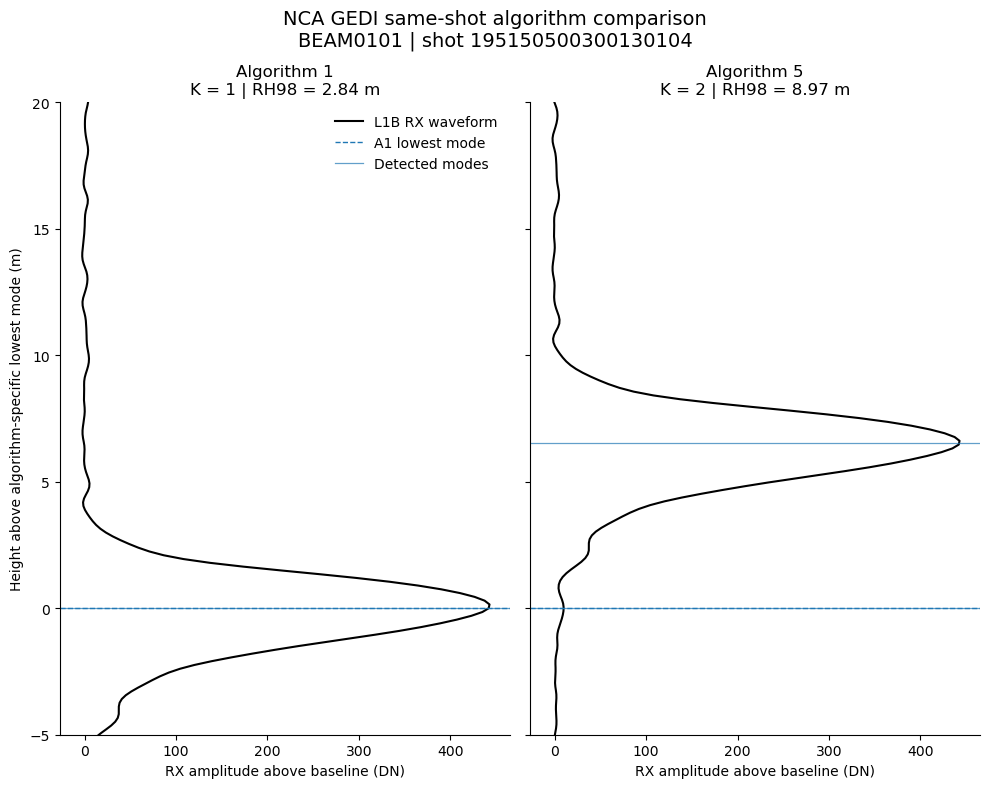

,value
granule_key,O19515_03_T08406_02
beam,BEAM0101
shot_number,195150500300130104
quality_flag,1
degrade_flag,0
sensitivity,0.957076
selected_algorithm,1
num_detectedmodes_root,1
K_a1,1.0
K_a5,2.0


In [18]:

# =============================================================================
# 11. SAME SHOT — A1 VS A5
# =============================================================================

# Example manual selector:
#
# SHOT_SELECTOR = {
#     "granule_key": "O23299_03_T01444_02",
#     "beam": "BEAM1000",
#     "shot_number": 232990800300243995,
# }
#
SHOT_SELECTOR = None


candidates = (
    gedi_keep[
        gedi_keep[
            "beam"
        ].isin(
            POWER_BEAMS
        )
    ]
    .copy()
)


if SHOT_SELECTOR is None:

    differing = candidates[
        candidates[
            "K_a1"
        ]
        !=
        candidates[
            "K_a5"
        ]
    ]


    if differing.empty:

        differing = candidates


    row = differing.sample(
        n=1,
        random_state=RANDOM_SEED,
    ).iloc[0]


else:

    m = (
        (
            candidates[
                "granule_key"
            ]
            == SHOT_SELECTOR[
                "granule_key"
            ]
        )
        &
        (
            candidates[
                "beam"
            ]
            == SHOT_SELECTOR[
                "beam"
            ]
        )
        &
        (
            candidates[
                "shot_number"
            ].astype(
                np.uint64
            )
            ==
            np.uint64(
                SHOT_SELECTOR[
                    "shot_number"
                ]
            )
        )
    )


    if m.sum() != 1:

        raise KeyError(
            "SHOT_SELECTOR did not identify "
            "exactly one retained shot."
        )


    row = candidates.loc[
        m
    ].iloc[0]


wf = read_l1b_vertical_waveform(
    row[
        "granule_key"
    ],
    row[
        "beam"
    ],
    int(
        row[
            "shot_number"
        ]
    ),
)


modes1 = algorithm_mode_elevations_for_shot(
    row[
        "granule_key"
    ],
    row[
        "beam"
    ],
    int(
        row[
            "shot_number"
        ]
    ),
    alg=1,
    waveform_z_min=wf[
        "z_min"
    ],
    waveform_z_max=wf[
        "z_max"
    ],
)


modes5 = algorithm_mode_elevations_for_shot(
    row[
        "granule_key"
    ],
    row[
        "beam"
    ],
    int(
        row[
            "shot_number"
        ]
    ),
    alg=5,
    waveform_z_min=wf[
        "z_min"
    ],
    waveform_z_max=wf[
        "z_max"
    ],
)


ground1 = float(
    row[
        "elev_lowestmode_a1"
    ]
)

ground5 = float(
    row[
        "elev_lowestmode_a5"
    ]
)


height1 = (
    wf[
        "elevation_m"
    ]
    - ground1
)

height5 = (
    wf[
        "elevation_m"
    ]
    - ground5
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        10,
        8,
    ),
    sharex=True,
    sharey=True,
)


for (
    ax,
    alg,
    height,
    ground,
    modes,
) in [

    (
        axes[0],
        1,
        height1,
        ground1,
        modes1,
    ),

    (
        axes[1],
        5,
        height5,
        ground5,
        modes5,
    ),
]:


    ax.plot(
        wf[
            "rx_corrected"
        ],
        height,
        color="black",
        linewidth=1.5,
        label="L1B RX waveform",
    )


    ax.axhline(
        0,
        linestyle="--",
        linewidth=1.0,
        label=f"A{alg} lowest mode",
    )


    for j, zmode in enumerate(
        modes
    ):

        hmode = (
            zmode
            - ground
        )


        if (
            HEIGHT_MIN_M
            <= hmode
            <= HEIGHT_MAX_M
        ):

            ax.axhline(
                hmode,
                linewidth=0.9,
                alpha=0.7,
                label=(
                    "Detected modes"
                    if j == 0
                    else None
                ),
            )


    ax.set_ylim(
        HEIGHT_MIN_M,
        HEIGHT_MAX_M,
    )

    ax.set_xlabel(
        "RX amplitude above baseline (DN)"
    )

    ax.set_title(
        f"Algorithm {alg}\n"
        f"K = {int(row[f'K_a{alg}'])} | "
        f"RH98 = {row[f'rh98_a{alg}']:.2f} m"
    )

    ax.spines[
        "top"
    ].set_visible(
        False
    )

    ax.spines[
        "right"
    ].set_visible(
        False
    )


axes[0].set_ylabel(
    "Height above algorithm-specific lowest mode (m)"
)

axes[0].legend(
    frameon=False,
    loc="upper right",
)


fig.suptitle(
    f"NCA GEDI same-shot algorithm comparison\n"
    f"{row['beam']} | "
    f"shot {int(row['shot_number'])}",
    fontsize=14,
)

fig.tight_layout()

plt.show()


display(
    row[
        [
            "granule_key",
            "beam",
            "shot_number",
            "quality_flag",
            "degrade_flag",
            "sensitivity",
            "selected_algorithm",
            "num_detectedmodes_root",
            "K_a1",
            "K_a5",
            "elev_lowestmode_a1",
            "elev_lowestmode_a5",
            "rh98_a1",
            "rh98_a5",
            "delta_K_a5_minus_a1",
            "delta_ground_a5_minus_a1_m",
            "delta_rh98_a5_minus_a1_m",
        ]
    ].to_frame(
        "value"
    )
)



## 9. Representative matched A1/A5 cases

These cases preserve the same-shot comparison:

- A1 and A5 agree on \(K\)
- A5 adds one or more modes
- A5 removes one or more modes
- large lowest-mode elevation disagreement

The large-shift class is particularly useful for identifying cases where A5 may be locking onto weak/noise-like low-elevation structure.


In [19]:

# =============================================================================
# 12. SELECT REPRESENTATIVE MATCHED CASES
# =============================================================================

plot_pool = (
    gedi_keep[
        gedi_keep[
            "beam"
        ].isin(
            POWER_BEAMS
        )
    ]
    .copy()
)


plot_pool[
    "abs_ground_shift"
] = np.abs(
    plot_pool[
        "delta_ground_a5_minus_a1_m"
    ]
)


categories = {}


# -----------------------------------------------------------------------------
# K agreement
# -----------------------------------------------------------------------------

agree = plot_pool[
    plot_pool[
        "K_a1"
    ]
    ==
    plot_pool[
        "K_a5"
    ]
]


if len(
    agree
):

    categories[
        "K agreement"
    ] = agree.sample(
        1,
        random_state=RANDOM_SEED,
    ).iloc[0]


# -----------------------------------------------------------------------------
# A5 adds mode(s)
# -----------------------------------------------------------------------------

adds = plot_pool[
    plot_pool[
        "K_a5"
    ]
    >
    plot_pool[
        "K_a1"
    ]
]


if len(
    adds
):

    median_shift = adds[
        "delta_ground_a5_minus_a1_m"
    ].median()

    categories[
        "A5 adds mode(s)"
    ] = (
        adds.assign(
            _distance=np.abs(
                adds[
                    "delta_ground_a5_minus_a1_m"
                ]
                - median_shift
            )
        )
        .sort_values(
            "_distance"
        )
        .iloc[0]
    )


# -----------------------------------------------------------------------------
# A5 removes mode(s)
# -----------------------------------------------------------------------------

removes = plot_pool[
    plot_pool[
        "K_a5"
    ]
    <
    plot_pool[
        "K_a1"
    ]
]


if len(
    removes
):

    median_shift = removes[
        "delta_ground_a5_minus_a1_m"
    ].median()

    categories[
        "A5 removes mode(s)"
    ] = (
        removes.assign(
            _distance=np.abs(
                removes[
                    "delta_ground_a5_minus_a1_m"
                ]
                - median_shift
            )
        )
        .sort_values(
            "_distance"
        )
        .iloc[0]
    )


# -----------------------------------------------------------------------------
# Large ground-reference shift
# -----------------------------------------------------------------------------

if plot_pool[
    "abs_ground_shift"
].notna().any():

    categories[
        "Large ground-reference shift"
    ] = (
        plot_pool.nlargest(
            1,
            "abs_ground_shift",
        )
        .iloc[0]
    )


rep_cases = (
    pd.DataFrame(
        categories
    )
    .T
    .reset_index(
        names="case"
    )
)


display(
    rep_cases[
        [
            "case",
            "granule_key",
            "beam",
            "shot_number",
            "K_a1",
            "K_a5",
            "rh98_a1",
            "rh98_a5",
            "delta_ground_a5_minus_a1_m",
        ]
    ]
)


,case,granule_key,beam,shot_number,K_a1,K_a5,rh98_a1,rh98_a5,delta_ground_a5_minus_a1_m
0,K agreement,O05084_02_T05480_02,BEAM0110,50840600200334417,1.0,1.0,2.5,2.02,0.07489
1,A5 adds mode(s),O31718_02_T04868_02,BEAM1000,317180800200073582,1.0,2.0,2.57,9.4,-7.243774
2,Large ground-reference shift,O21758_03_T00021_02,BEAM1011,217581100300301703,1.0,3.0,2.73,106.76,-104.409912


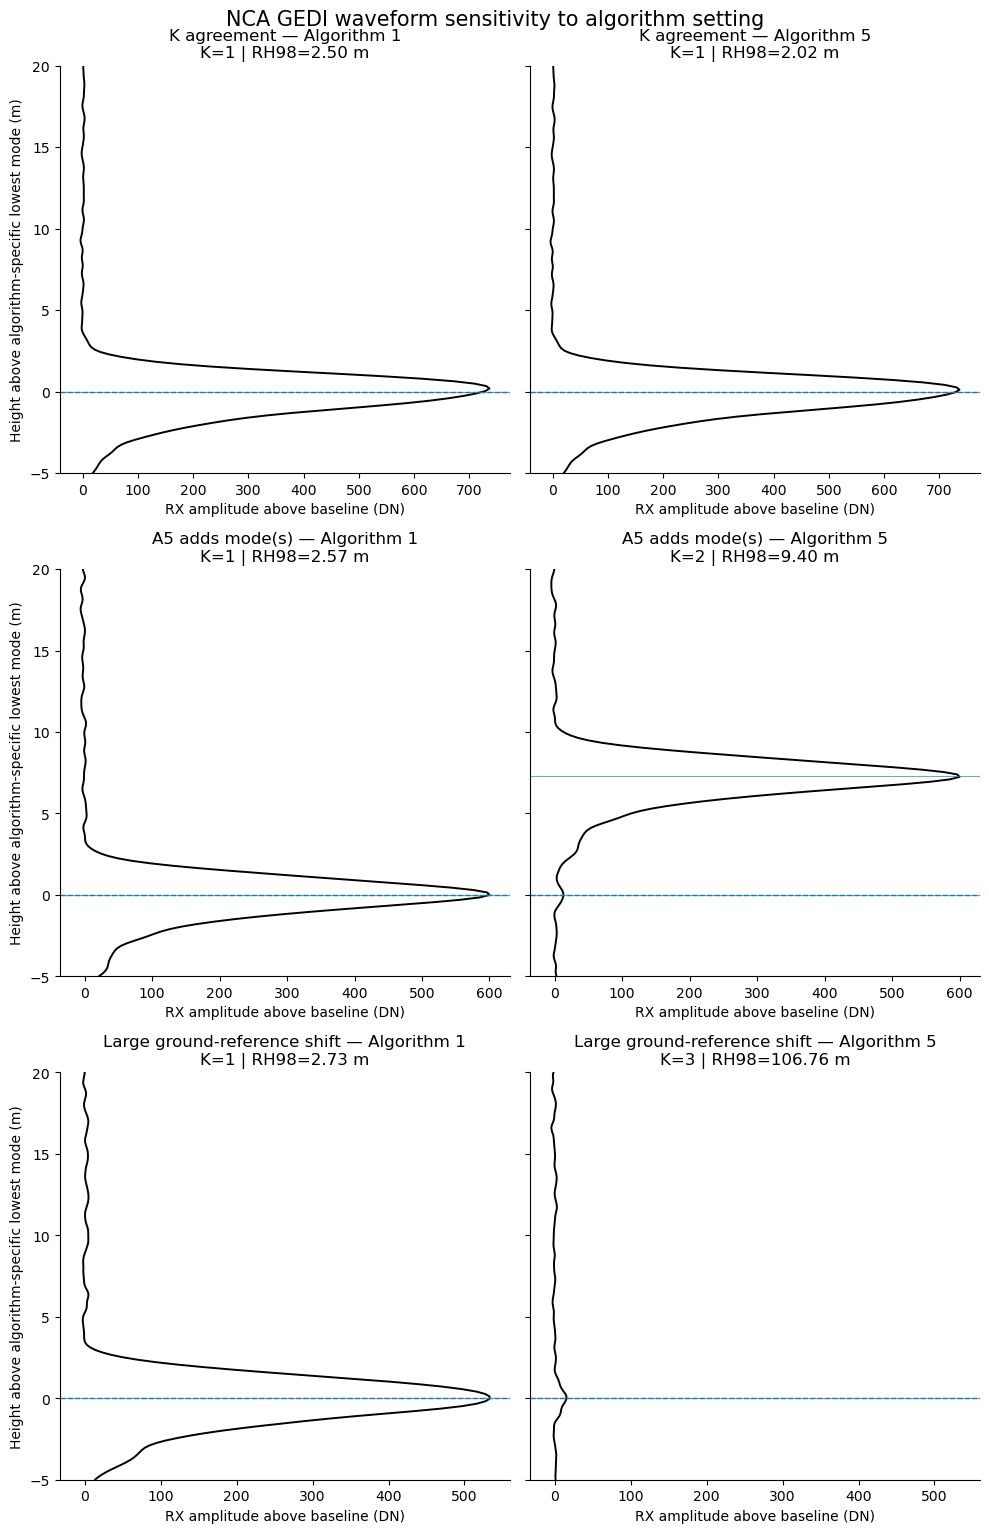

In [20]:

# =============================================================================
# 13. PRESENTATION FIGURE — MATCHED A1/A5 CASES
# =============================================================================

n_cases = len(
    rep_cases
)


fig, axes = plt.subplots(
    n_cases,
    2,
    figsize=(
        10,
        5.2 * n_cases,
    ),
    sharey=True,
    squeeze=False,
)


for i, case_row in rep_cases.iterrows():


    wf_i = read_l1b_vertical_waveform(
        case_row[
            "granule_key"
        ],
        case_row[
            "beam"
        ],
        int(
            case_row[
                "shot_number"
            ]
        ),
    )


    for j, alg in enumerate(
        [
            1,
            5,
        ]
    ):


        ax = axes[
            i,
            j,
        ]


        ground = float(
            case_row[
                f"elev_lowestmode_a{alg}"
            ]
        )


        modes = algorithm_mode_elevations_for_shot(
            case_row[
                "granule_key"
            ],
            case_row[
                "beam"
            ],
            int(
                case_row[
                    "shot_number"
                ]
            ),
            alg=alg,
            waveform_z_min=wf_i[
                "z_min"
            ],
            waveform_z_max=wf_i[
                "z_max"
            ],
        )


        height = (
            wf_i[
                "elevation_m"
            ]
            - ground
        )


        ax.plot(
            wf_i[
                "rx_corrected"
            ],
            height,
            color="black",
            linewidth=1.4,
        )


        ax.axhline(
            0,
            linestyle="--",
            linewidth=1,
        )


        for zmode in modes:

            hmode = (
                zmode
                - ground
            )


            if (
                HEIGHT_MIN_M
                <= hmode
                <= HEIGHT_MAX_M
            ):

                ax.axhline(
                    hmode,
                    linewidth=0.8,
                    alpha=0.65,
                )


        ax.set_ylim(
            HEIGHT_MIN_M,
            HEIGHT_MAX_M,
        )


        ax.set_xlabel(
            "RX amplitude above baseline (DN)"
        )


        ax.set_title(
            f"{case_row['case']} — Algorithm {alg}\n"
            f"K={int(case_row[f'K_a{alg}'])} | "
            f"RH98={case_row[f'rh98_a{alg}']:.2f} m"
        )


        ax.spines[
            "top"
        ].set_visible(
            False
        )

        ax.spines[
            "right"
        ].set_visible(
            False
        )


    axes[
        i,
        0,
    ].set_ylabel(
        "Height above algorithm-specific lowest mode (m)"
    )


fig.suptitle(
    "NCA GEDI waveform sensitivity to algorithm setting",
    fontsize=15,
)

fig.tight_layout()

plt.show()



## 10. Disagreement tail

The disagreement tail is a validation target rather than an automatic exclusion set.

Particularly important cases:

- \(K_5>K_1\) with small ground-reference shifts → possible recovery of weak shoulder structure
- strongly negative A5−A1 lowest-mode shifts → possible real weak lower return **or** false/noise-triggered lowest mode
- very large A5 RH98 values without coherent signal in the vertical waveform → likely algorithmic failure for that shot


In [21]:

# =============================================================================
# 14. DISAGREEMENT REVIEW TABLE
# =============================================================================

review = (
    gedi_keep
    .copy()
)


review[
    "abs_ground_shift_m"
] = np.abs(
    review[
        "delta_ground_a5_minus_a1_m"
    ]
)


review[
    "abs_rh98_shift_m"
] = np.abs(
    review[
        "delta_rh98_a5_minus_a1_m"
    ]
)


show_cols = [
    "granule_key",
    "beam",
    "shot_number",
    "sensitivity",
    "selected_algorithm",
    "num_detectedmodes_root",
    "K_a1",
    "K_a5",
    "delta_K_a5_minus_a1",
    "elev_lowestmode_a1",
    "elev_lowestmode_a5",
    "delta_ground_a5_minus_a1_m",
    "rh98_a1",
    "rh98_a5",
    "delta_rh98_a5_minus_a1_m",
]


print(
    "Largest increases in K under Algorithm 5"
)

display(
    review.sort_values(
        [
            "delta_K_a5_minus_a1",
            "abs_ground_shift_m",
        ],
        ascending=[
            False,
            False,
        ],
    )[
        show_cols
    ].head(
        30
    )
)


print(
    "\nLargest A1/A5 lowest-mode elevation disagreements"
)

display(
    review.nlargest(
        30,
        "abs_ground_shift_m",
    )[
        show_cols
    ]
)


Largest increases in K under Algorithm 5


,granule_key,beam,shot_number,sensitivity,selected_algorithm,num_detectedmodes_root,K_a1,K_a5,delta_K_a5_minus_a1,elev_lowestmode_a1,elev_lowestmode_a5,delta_ground_a5_minus_a1_m,rh98_a1,rh98_a5,delta_rh98_a5_minus_a1_m
239415,O17669_03_T05713_02,BEAM1000,176690800300244432,0.941124,1,1,1.0,20.0,19.0,1265.318848,1194.521729,-70.797119,5.05,74.87,69.82
239396,O17669_03_T05713_02,BEAM1000,176690800300244388,0.939658,1,1,1.0,20.0,19.0,1303.004395,1235.125977,-67.878418,3.21,69.86,66.65
239401,O17669_03_T05713_02,BEAM1000,176690800300244402,0.937325,1,1,1.0,20.0,19.0,1311.859985,1246.600830,-65.259155,4.90,69.07,64.17
239311,O17669_03_T05713_02,BEAM0110,176690600300539192,0.945287,1,1,1.0,20.0,19.0,1304.558716,1239.880615,-64.678101,6.43,69.69,63.26
239409,O17669_03_T05713_02,BEAM1000,176690800300244416,0.941382,1,1,1.0,20.0,19.0,1289.891357,1227.812866,-62.078491,7.48,68.51,61.03
239400,O17669_03_T05713_02,BEAM1000,176690800300244398,0.940505,1,1,1.0,20.0,19.0,1269.817505,1208.562378,-61.255127,7.67,67.80,60.13
239384,O17669_03_T05713_02,BEAM1000,176690800300244354,0.933549,1,1,1.0,20.0,19.0,1250.305786,1189.387329,-60.918457,7.70,67.65,59.95
239230,O17669_03_T05713_02,BEAM0101,176690500300240846,0.952038,1,1,1.0,20.0,19.0,1337.144653,1277.484741,-59.659912,4.94,63.58,58.64
239285,O17669_03_T05713_02,BEAM0110,176690600300539111,0.922710,1,1,1.0,20.0,19.0,1314.581787,1255.405762,-59.176025,4.56,62.95,58.39
239516,O17669_03_T05713_02,BEAM1011,176691100300240646,0.955090,1,1,1.0,20.0,19.0,1238.463623,1179.899780,-58.563843,5.94,63.42,57.48



Largest A1/A5 lowest-mode elevation disagreements


,granule_key,beam,shot_number,sensitivity,selected_algorithm,num_detectedmodes_root,K_a1,K_a5,delta_K_a5_minus_a1,elev_lowestmode_a1,elev_lowestmode_a5,delta_ground_a5_minus_a1_m,rh98_a1,rh98_a5,delta_rh98_a5_minus_a1_m
422503,O23772_03_T09829_02,BEAM0011,237720300300241933,0.902538,1,1,1.0,3.0,2.0,909.074768,765.064514,-144.010254,2.47,146.14,143.67
10456,O02202_03_T00174_02,BEAM0001,22020100300127742,0.914293,1,1,1.0,4.0,3.0,901.969910,797.509827,-104.460083,2.73,106.78,104.05
56517,O02920_03_T05407_02,BEAM0011,29200300300242386,0.919118,1,1,1.0,3.0,2.0,827.147156,722.715454,-104.431702,2.84,107.09,104.25
362768,O21758_03_T00021_02,BEAM1011,217581100300301703,0.967169,1,1,1.0,3.0,2.0,946.195801,841.785889,-104.409912,2.73,106.76,104.03
3991,O02061_02_T00905_02,BEAM1011,20611100200087493,0.983738,1,1,1.0,6.0,5.0,774.495178,670.123291,-104.371887,2.39,106.28,103.89
379536,O22609_02_T10101_02,BEAM0010,226090200200071911,0.933722,1,1,1.0,2.0,1.0,889.040100,785.202637,-103.837463,2.58,106.08,103.50
62959,O03283_02_T03445_02,BEAM0011,32830300200088240,0.959097,1,1,1.0,3.0,2.0,957.790283,854.291565,-103.498718,2.69,105.78,103.09
431541,O31123_02_T06291_02,BEAM0011,311230300200070011,0.914483,1,1,1.0,4.0,3.0,838.500977,735.175293,-103.325684,2.80,105.75,102.95
431674,O31123_02_T06291_02,BEAM0011,311230300200070257,0.917758,1,1,1.0,3.0,2.0,853.833496,750.881287,-102.952209,2.69,105.26,102.57
114720,O08855_03_T02714_02,BEAM0010,88550200300250023,0.909945,1,1,1.0,3.0,2.0,878.276855,775.439514,-102.837341,3.28,105.93,102.65



## Interpretation checkpoint

Do not choose Algorithm 5 because it detects more modes.

The decision should depend on whether its added sensitivity is physically useful in this dryland setting.

A defensible primary algorithm should show:

1. mode counts consistent with the actual waveform morphology;
2. lowest-mode elevations that remain tied to coherent signal rather than low-amplitude noise;
3. stable RH metrics;
4. sensible behavior across terrain and acquisition conditions;
5. improved ecological/physical interpretation rather than simply increased structural complexity.

Until those conditions are demonstrated, treat A1 and A5 as parallel processing representations.


c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


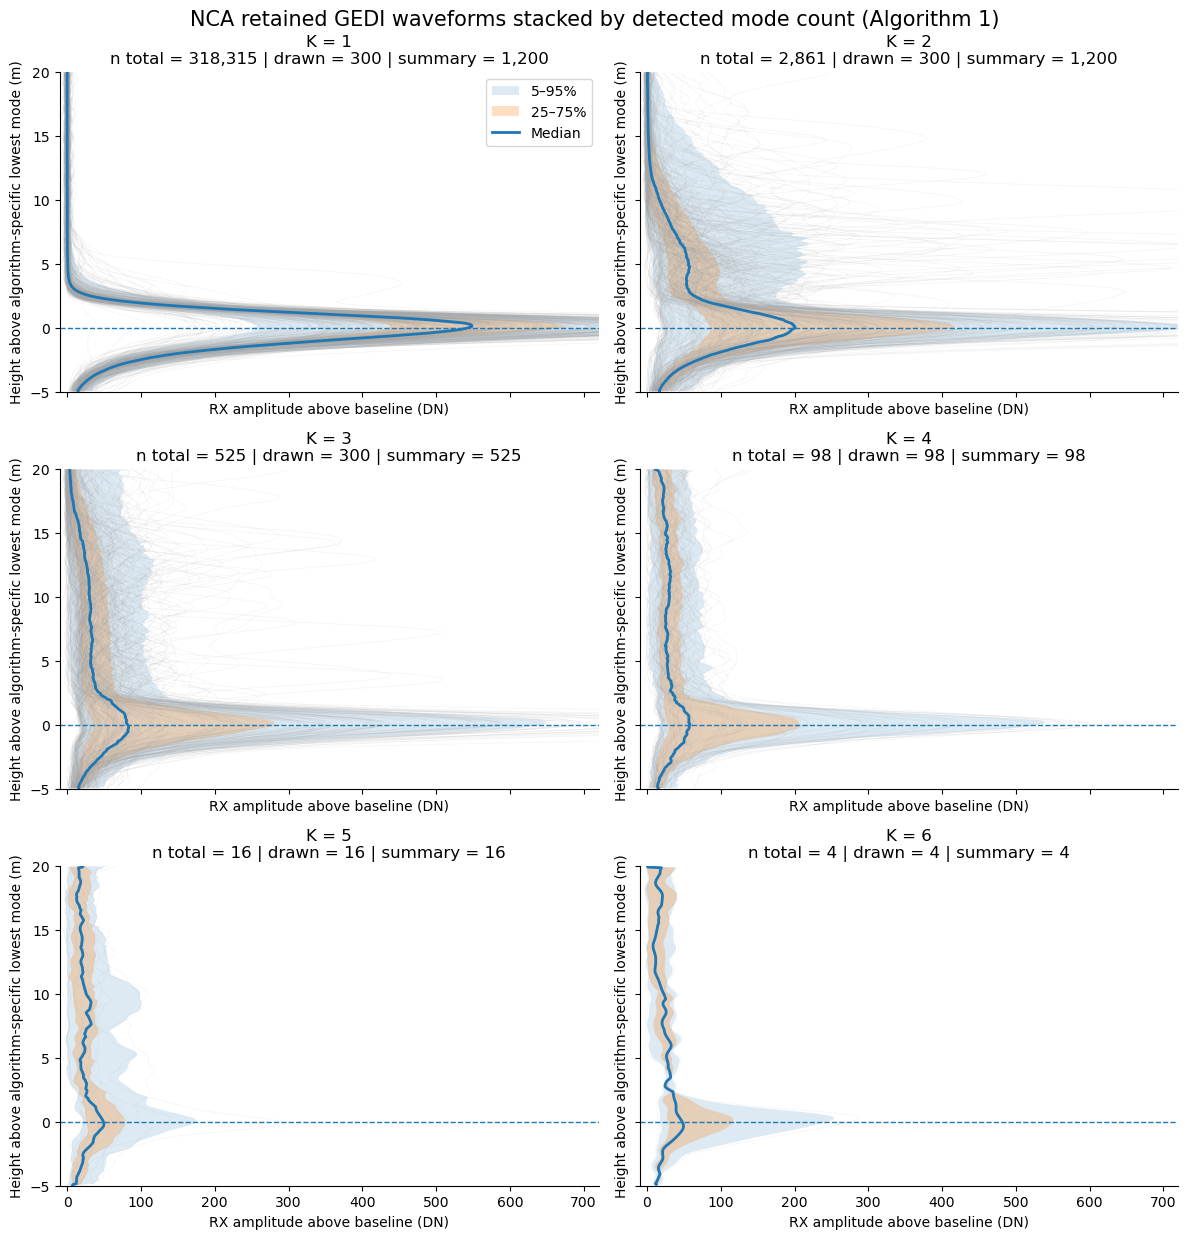

In [22]:
# =============================================================================
# STACKED VERTICAL WAVEFORMS BY K
# Height on y-axis, DN on x-axis
# Works in the NCA A1 vs A5 notebook
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# USER CONTROLS
# -----------------------------------------------------------------------------

ALGORITHM = 1                  # set to 1 or 5
USE_POWER_BEAMS_ONLY = True    # recommended
USE_BASELINE_CORRECTED = True  # True = DN above baseline; False = raw DN

HEIGHT_MIN_M = -5
HEIGHT_MAX_M = 20
HEIGHT_GRID_N = 500

# How many waveforms to draw in each panel
MAX_PLOTTED_PER_K = 300

# How many waveforms to use for the envelope stats in each panel
MAX_SUMMARY_PER_K = 1200

# Which K values to show; if None, use all available K in the retained subset
TARGET_KS = None

RANDOM_SEED = 42


# -----------------------------------------------------------------------------
# INTERNAL COLUMN LOGIC
# -----------------------------------------------------------------------------

K_COL = f"K_a{ALGORITHM}"
GROUND_COL = f"elev_lowestmode_a{ALGORITHM}"

if K_COL not in gedi_keep.columns:
    raise KeyError(f"{K_COL} not found in gedi_keep")

if GROUND_COL not in gedi_keep.columns:
    raise KeyError(f"{GROUND_COL} not found in gedi_keep")


# -----------------------------------------------------------------------------
# PLOT POOL
# -----------------------------------------------------------------------------

plot_pool = gedi_keep.copy()

if USE_POWER_BEAMS_ONLY:
    plot_pool = plot_pool[
        plot_pool["beam"].isin(POWER_BEAMS)
    ].copy()

plot_pool = plot_pool[
    plot_pool[K_COL].notna()
].copy()

plot_pool[K_COL] = plot_pool[K_COL].astype(int)

if TARGET_KS is None:
    ks = sorted(plot_pool[K_COL].unique())
else:
    ks = [k for k in TARGET_KS if k in set(plot_pool[K_COL].unique())]

if len(ks) == 0:
    raise ValueError("No K values available under current filters.")


# -----------------------------------------------------------------------------
# HELPERS
# -----------------------------------------------------------------------------

height_grid = np.linspace(
    HEIGHT_MIN_M,
    HEIGHT_MAX_M,
    HEIGHT_GRID_N,
)

rng = np.random.default_rng(RANDOM_SEED)


def waveform_x_field(wf_dict, use_baseline_corrected=True):
    if use_baseline_corrected:
        return np.asarray(wf_dict["rx_corrected"], dtype=float)
    return np.asarray(wf_dict["rx_raw"], dtype=float)


def vertical_profile_for_row(row):
    """
    Returns:
        height_trim : waveform height relative to algorithm-specific lowest mode
        x_trim      : DN/amplitude values matched to height_trim
    """
    wf = read_l1b_vertical_waveform(
        row["granule_key"],
        row["beam"],
        int(row["shot_number"]),
    )

    ground = float(row[GROUND_COL])

    height = np.asarray(wf["elevation_m"], dtype=float) - ground
    x = waveform_x_field(
        wf,
        use_baseline_corrected=USE_BASELINE_CORRECTED,
    )

    valid = np.isfinite(height) & np.isfinite(x)
    height = height[valid]
    x = x[valid]

    if len(height) < 5:
        return None, None

    # Ensure monotonic height for interpolation
    order = np.argsort(height)
    height = height[order]
    x = x[order]

    # Trim to requested vertical window
    keep = (
        (height >= HEIGHT_MIN_M)
        & (height <= HEIGHT_MAX_M)
    )

    height_trim = height[keep]
    x_trim = x[keep]

    if len(height_trim) < 5:
        return None, None

    return height_trim, x_trim


def interpolate_to_common_height(height, x, target_grid):
    """
    Interpolate x(height) onto a common height grid.
    Outside observed range, return NaN.
    """
    if height is None or x is None or len(height) < 5:
        return np.full_like(target_grid, np.nan, dtype=float)

    return np.interp(
        target_grid,
        height,
        x,
        left=np.nan,
        right=np.nan,
    )


# -----------------------------------------------------------------------------
# BUILD PANEL DATA
# -----------------------------------------------------------------------------

panel_data = {}
all_interp_values = []

for k in ks:
    dfk = plot_pool[
        plot_pool[K_COL] == k
    ].copy()

    n_total = len(dfk)

    if n_total == 0:
        continue

    # Sample for visible lines
    n_plot = min(MAX_PLOTTED_PER_K, n_total)
    draw_idx = rng.choice(n_total, size=n_plot, replace=False)
    draw_df = dfk.iloc[draw_idx].reset_index(drop=True)

    # Sample for summary envelopes
    n_summary = min(MAX_SUMMARY_PER_K, n_total)
    summary_idx = rng.choice(n_total, size=n_summary, replace=False)
    summary_df = dfk.iloc[summary_idx].reset_index(drop=True)

    plotted_profiles = []
    interp_profiles = []

    # Profiles to draw
    for _, row in draw_df.iterrows():
        h, x = vertical_profile_for_row(row)
        if h is None:
            continue
        plotted_profiles.append((h, x))

    # Profiles for interpolation and summary
    for _, row in summary_df.iterrows():
        h, x = vertical_profile_for_row(row)
        if h is None:
            continue

        xi = interpolate_to_common_height(
            h,
            x,
            height_grid,
        )

        interp_profiles.append(xi)
        all_interp_values.append(xi)

    if len(interp_profiles) == 0:
        continue

    interp_arr = np.vstack(interp_profiles)

    panel_data[k] = {
        "n_total": n_total,
        "n_plot": len(plotted_profiles),
        "n_summary": interp_arr.shape[0],
        "plotted_profiles": plotted_profiles,
        "interp_arr": interp_arr,
    }


if len(panel_data) == 0:
    raise ValueError("No panel data were produced.")


# -----------------------------------------------------------------------------
# COMMON X LIMITS
# -----------------------------------------------------------------------------

flat = np.concatenate([
    arr[np.isfinite(arr)]
    for arr in all_interp_values
    if np.isfinite(arr).any()
])

if USE_BASELINE_CORRECTED:
    x_lo = np.nanpercentile(flat, 0.5)
    x_hi = np.nanpercentile(flat, 99.5)
    x_lo = min(-10, x_lo)
else:
    x_lo = np.nanpercentile(flat, 0.5)
    x_hi = np.nanpercentile(flat, 99.5)

x_hi = max(x_hi, 50)


# -----------------------------------------------------------------------------
# FIGURE LAYOUT
# -----------------------------------------------------------------------------

n_panels = len(panel_data)
ncols = 2
nrows = int(np.ceil(n_panels / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(12, 4.2 * nrows),
    sharex=True,
    sharey=True,
    squeeze=False,
)

axes = axes.ravel()


# -----------------------------------------------------------------------------
# DRAW PANELS
# -----------------------------------------------------------------------------

for ax, k in zip(axes, sorted(panel_data.keys())):
    d = panel_data[k]

    # thin individual waveforms
    for h, x in d["plotted_profiles"]:
        ax.plot(
            x,
            h,
            color="0.65",
            alpha=0.12,
            linewidth=0.5,
        )

    interp_arr = d["interp_arr"]

    q05 = np.nanpercentile(interp_arr, 5, axis=0)
    q25 = np.nanpercentile(interp_arr, 25, axis=0)
    q50 = np.nanpercentile(interp_arr, 50, axis=0)
    q75 = np.nanpercentile(interp_arr, 75, axis=0)
    q95 = np.nanpercentile(interp_arr, 95, axis=0)

    ax.fill_betweenx(
        height_grid,
        q05,
        q95,
        alpha=0.15,
        label="5–95%",
    )

    ax.fill_betweenx(
        height_grid,
        q25,
        q75,
        alpha=0.25,
        label="25–75%",
    )

    ax.plot(
        q50,
        height_grid,
        linewidth=2.0,
        label="Median",
    )

    ax.axhline(
        0,
        linestyle="--",
        linewidth=1.0,
    )

    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(HEIGHT_MIN_M, HEIGHT_MAX_M)

    ax.set_title(
        f"K = {k}\n"
        f"n total = {d['n_total']:,} | "
        f"drawn = {d['n_plot']:,} | "
        f"summary = {d['n_summary']:,}"
    )

    ax.set_xlabel(
        "RX amplitude above baseline (DN)"
        if USE_BASELINE_CORRECTED
        else "Raw RX amplitude (DN)"
    )

    ax.set_ylabel(
        "Height above algorithm-specific lowest mode (m)"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if k == sorted(panel_data.keys())[0]:
        ax.legend(loc="upper right")


# turn off unused axes
for ax in axes[len(panel_data):]:
    ax.axis("off")


fig.suptitle(
    f"NCA retained GEDI waveforms stacked by detected mode count "
    f"(Algorithm {ALGORITHM})",
    fontsize=15,
)

fig.tight_layout()
plt.show()

c:\Users\scottfordham\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


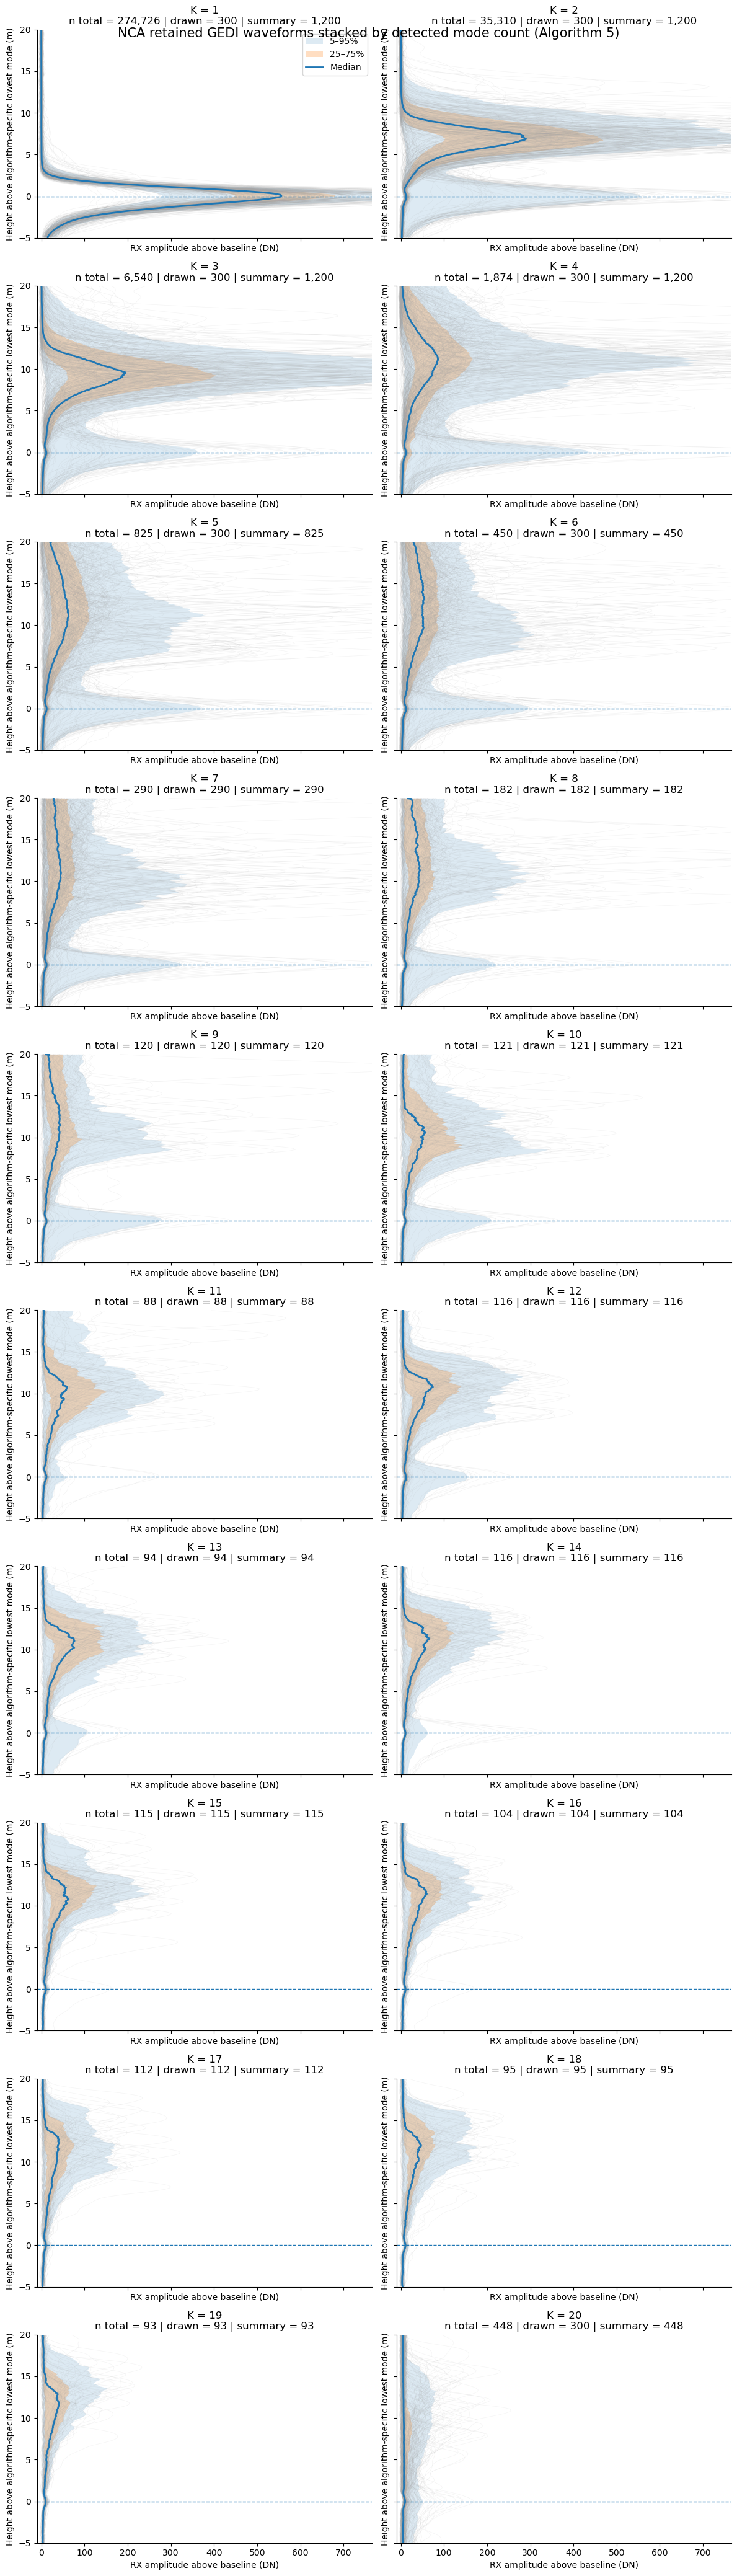

In [23]:
# =============================================================================
# STACKED VERTICAL WAVEFORMS BY K
# Height on y-axis, DN on x-axis
# Works in the NCA A1 vs A5 notebook
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# USER CONTROLS
# -----------------------------------------------------------------------------

ALGORITHM = 5                  # set to 1 or 5
USE_POWER_BEAMS_ONLY = True    # recommended
USE_BASELINE_CORRECTED = True  # True = DN above baseline; False = raw DN

HEIGHT_MIN_M = -5
HEIGHT_MAX_M = 20
HEIGHT_GRID_N = 500

# How many waveforms to draw in each panel
MAX_PLOTTED_PER_K = 300

# How many waveforms to use for the envelope stats in each panel
MAX_SUMMARY_PER_K = 1200

# Which K values to show; if None, use all available K in the retained subset
TARGET_KS = None

RANDOM_SEED = 42


# -----------------------------------------------------------------------------
# INTERNAL COLUMN LOGIC
# -----------------------------------------------------------------------------

K_COL = f"K_a{ALGORITHM}"
GROUND_COL = f"elev_lowestmode_a{ALGORITHM}"

if K_COL not in gedi_keep.columns:
    raise KeyError(f"{K_COL} not found in gedi_keep")

if GROUND_COL not in gedi_keep.columns:
    raise KeyError(f"{GROUND_COL} not found in gedi_keep")


# -----------------------------------------------------------------------------
# PLOT POOL
# -----------------------------------------------------------------------------

plot_pool = gedi_keep.copy()

if USE_POWER_BEAMS_ONLY:
    plot_pool = plot_pool[
        plot_pool["beam"].isin(POWER_BEAMS)
    ].copy()

plot_pool = plot_pool[
    plot_pool[K_COL].notna()
].copy()

plot_pool[K_COL] = plot_pool[K_COL].astype(int)

if TARGET_KS is None:
    ks = sorted(plot_pool[K_COL].unique())
else:
    ks = [k for k in TARGET_KS if k in set(plot_pool[K_COL].unique())]

if len(ks) == 0:
    raise ValueError("No K values available under current filters.")


# -----------------------------------------------------------------------------
# HELPERS
# -----------------------------------------------------------------------------

height_grid = np.linspace(
    HEIGHT_MIN_M,
    HEIGHT_MAX_M,
    HEIGHT_GRID_N,
)

rng = np.random.default_rng(RANDOM_SEED)


def waveform_x_field(wf_dict, use_baseline_corrected=True):
    if use_baseline_corrected:
        return np.asarray(wf_dict["rx_corrected"], dtype=float)
    return np.asarray(wf_dict["rx_raw"], dtype=float)


def vertical_profile_for_row(row):
    """
    Returns:
        height_trim : waveform height relative to algorithm-specific lowest mode
        x_trim      : DN/amplitude values matched to height_trim
    """
    wf = read_l1b_vertical_waveform(
        row["granule_key"],
        row["beam"],
        int(row["shot_number"]),
    )

    ground = float(row[GROUND_COL])

    height = np.asarray(wf["elevation_m"], dtype=float) - ground
    x = waveform_x_field(
        wf,
        use_baseline_corrected=USE_BASELINE_CORRECTED,
    )

    valid = np.isfinite(height) & np.isfinite(x)
    height = height[valid]
    x = x[valid]

    if len(height) < 5:
        return None, None

    # Ensure monotonic height for interpolation
    order = np.argsort(height)
    height = height[order]
    x = x[order]

    # Trim to requested vertical window
    keep = (
        (height >= HEIGHT_MIN_M)
        & (height <= HEIGHT_MAX_M)
    )

    height_trim = height[keep]
    x_trim = x[keep]

    if len(height_trim) < 5:
        return None, None

    return height_trim, x_trim


def interpolate_to_common_height(height, x, target_grid):
    """
    Interpolate x(height) onto a common height grid.
    Outside observed range, return NaN.
    """
    if height is None or x is None or len(height) < 5:
        return np.full_like(target_grid, np.nan, dtype=float)

    return np.interp(
        target_grid,
        height,
        x,
        left=np.nan,
        right=np.nan,
    )


# -----------------------------------------------------------------------------
# BUILD PANEL DATA
# -----------------------------------------------------------------------------

panel_data = {}
all_interp_values = []

for k in ks:
    dfk = plot_pool[
        plot_pool[K_COL] == k
    ].copy()

    n_total = len(dfk)

    if n_total == 0:
        continue

    # Sample for visible lines
    n_plot = min(MAX_PLOTTED_PER_K, n_total)
    draw_idx = rng.choice(n_total, size=n_plot, replace=False)
    draw_df = dfk.iloc[draw_idx].reset_index(drop=True)

    # Sample for summary envelopes
    n_summary = min(MAX_SUMMARY_PER_K, n_total)
    summary_idx = rng.choice(n_total, size=n_summary, replace=False)
    summary_df = dfk.iloc[summary_idx].reset_index(drop=True)

    plotted_profiles = []
    interp_profiles = []

    # Profiles to draw
    for _, row in draw_df.iterrows():
        h, x = vertical_profile_for_row(row)
        if h is None:
            continue
        plotted_profiles.append((h, x))

    # Profiles for interpolation and summary
    for _, row in summary_df.iterrows():
        h, x = vertical_profile_for_row(row)
        if h is None:
            continue

        xi = interpolate_to_common_height(
            h,
            x,
            height_grid,
        )

        interp_profiles.append(xi)
        all_interp_values.append(xi)

    if len(interp_profiles) == 0:
        continue

    interp_arr = np.vstack(interp_profiles)

    panel_data[k] = {
        "n_total": n_total,
        "n_plot": len(plotted_profiles),
        "n_summary": interp_arr.shape[0],
        "plotted_profiles": plotted_profiles,
        "interp_arr": interp_arr,
    }


if len(panel_data) == 0:
    raise ValueError("No panel data were produced.")


# -----------------------------------------------------------------------------
# COMMON X LIMITS
# -----------------------------------------------------------------------------

flat = np.concatenate([
    arr[np.isfinite(arr)]
    for arr in all_interp_values
    if np.isfinite(arr).any()
])

if USE_BASELINE_CORRECTED:
    x_lo = np.nanpercentile(flat, 0.5)
    x_hi = np.nanpercentile(flat, 99.5)
    x_lo = min(-10, x_lo)
else:
    x_lo = np.nanpercentile(flat, 0.5)
    x_hi = np.nanpercentile(flat, 99.5)

x_hi = max(x_hi, 50)


# -----------------------------------------------------------------------------
# FIGURE LAYOUT
# -----------------------------------------------------------------------------

n_panels = len(panel_data)
ncols = 2
nrows = int(np.ceil(n_panels / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(12, 4.2 * nrows),
    sharex=True,
    sharey=True,
    squeeze=False,
)

axes = axes.ravel()


# -----------------------------------------------------------------------------
# DRAW PANELS
# -----------------------------------------------------------------------------

for ax, k in zip(axes, sorted(panel_data.keys())):
    d = panel_data[k]

    # thin individual waveforms
    for h, x in d["plotted_profiles"]:
        ax.plot(
            x,
            h,
            color="0.65",
            alpha=0.12,
            linewidth=0.5,
        )

    interp_arr = d["interp_arr"]

    q05 = np.nanpercentile(interp_arr, 5, axis=0)
    q25 = np.nanpercentile(interp_arr, 25, axis=0)
    q50 = np.nanpercentile(interp_arr, 50, axis=0)
    q75 = np.nanpercentile(interp_arr, 75, axis=0)
    q95 = np.nanpercentile(interp_arr, 95, axis=0)

    ax.fill_betweenx(
        height_grid,
        q05,
        q95,
        alpha=0.15,
        label="5–95%",
    )

    ax.fill_betweenx(
        height_grid,
        q25,
        q75,
        alpha=0.25,
        label="25–75%",
    )

    ax.plot(
        q50,
        height_grid,
        linewidth=2.0,
        label="Median",
    )

    ax.axhline(
        0,
        linestyle="--",
        linewidth=1.0,
    )

    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(HEIGHT_MIN_M, HEIGHT_MAX_M)

    ax.set_title(
        f"K = {k}\n"
        f"n total = {d['n_total']:,} | "
        f"drawn = {d['n_plot']:,} | "
        f"summary = {d['n_summary']:,}"
    )

    ax.set_xlabel(
        "RX amplitude above baseline (DN)"
        if USE_BASELINE_CORRECTED
        else "Raw RX amplitude (DN)"
    )

    ax.set_ylabel(
        "Height above algorithm-specific lowest mode (m)"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if k == sorted(panel_data.keys())[0]:
        ax.legend(loc="upper right")


# turn off unused axes
for ax in axes[len(panel_data):]:
    ax.axis("off")


fig.suptitle(
    f"NCA retained GEDI waveforms stacked by detected mode count "
    f"(Algorithm {ALGORITHM})",
    fontsize=15,
)

fig.tight_layout()
plt.show()